# Previsão de Volume de Incidentes — Albus Hub
### Challenge Locaweb/FIAP 2026 · Frente de Machine Learning (Integrante 2)

Este notebook contém **todo o trabalho**: do arquivo bruto até a previsão final, passando por
**cada experimento que rodamos** — inclusive os que deram errado e as hipóteses que o dado
refutou.

**Estrutura:**

| Parte | O quê |
|---|---|
| 1–2 | O problema e a matéria-prima |
| 3–5 | **EDA**: por que os dados oscilam, as cascatas, a anatomia de cada prioridade |
| 6–7 | Como o modelo aprende e a escada de algoritmos |
| 8 | Carregar o motor (o pipeline de produção) |
| **9** | **Os 5 experimentos** — baseline justo, robustez, estabilidade, janela de treino, seleção honesta |
| 10–12 | O que os experimentos decidiram, resultados finais e conclusões |

**Versão acadêmica autocontida:** para atender ao formato de arquivo único da disciplina, as funções do `pipeline_prioridades.py` foram incorporadas ao próprio notebook. A lógica de modelagem é a mesma da versão v3.2; a adaptação serve apenas para que o `.ipynb` possa ser lido e executado sem depender de um módulo Python externo.

**Versão do modelo:** `volume_v3.2_2026-08-21`

⏱️ Execução completa: **~15 min** na primeira vez (a seção 9 cacheia os resultados; depois cai
para ~3 min).

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Localiza a pasta ml_volume de forma robusta: o Jupyter abre na pasta do notebook,
# mas o VS Code pode abrir na raiz do repositorio. Procuramos onde o dado esta.
def achar_ml():
    cwd = os.getcwd()
    for cand in [cwd, os.path.join(cwd, "ml_volume"), os.path.dirname(cwd),
                 os.path.join(os.path.dirname(cwd), "ml_volume")]:
        if os.path.exists(os.path.join(cand, "data", "incidents.parquet")):
            return os.path.abspath(cand)
    raise FileNotFoundError(
        "Nao achei 'data/incidents.parquet'. Rode o notebook de dentro da pasta ml_volume "
        f"(diretorio atual: {cwd})")

ML = achar_ml()
os.chdir(ML)                                   # o pipeline usa caminhos relativos
if ML not in sys.path: sys.path.insert(0, ML)
CACHE = os.path.join(ML, "data", "incidents.parquet")

plt.rcParams.update({"figure.figsize":(13,4), "font.size":10, "axes.grid":True,
                     "grid.alpha":.25, "axes.spines.top":False, "axes.spines.right":False})
pd.set_option("display.width", 220)
print("pandas", pd.__version__, "| numpy", np.__version__)
print("dado tratado:", CACHE, "-", "existe" if os.path.exists(CACHE) else "NAO ENCONTRADO")

pandas 3.0.3 | numpy 2.5.1
dado tratado: /home/bruno/projetos/albus-hub-ml/ml_volume/data/incidents.parquet - existe


---
## 1. O problema

Prever **quantos incidentes serão abertos** amanhã (**D+1**) e daqui a uma semana (**D+7**),
por **prioridade** (P1–P5) e no total (ALL), entregando **um número e uma faixa de incerteza**.

É uma ferramenta de **apoio à decisão** — dimensionar plantão, antecipar pressão sobre times.
Não emite parecer.

---
## 2. A matéria-prima

O dataset da Locaweb tem **uma linha por incidente**. Antes de qualquer transformação, fizemos
backup do original com hash SHA-256 registrado — regra do projeto: **o bruto é fonte de verdade
e nunca é sobrescrito**. O que carregamos abaixo é o cache `.parquet` (mesmo conteúdo, abre
muito mais rápido).

In [2]:
df = pd.read_parquet(CACHE)
df["Aberto"] = pd.to_datetime(df["Aberto"])
df["dia"]    = df["Aberto"].dt.floor("D")
df["_prio"]  = df["Prioridade"].str.extract(r"^\s*(\d)").astype("Int64")

print(f"linhas x colunas : {df.shape[0]:,} x {df.shape[1]}")
print(f"chave 'Numero'   : {'100% unica (sem duplicata)' if df['Número'].is_unique else 'TEM DUPLICATA'}")
print(f"periodo 'Aberto' : {df['Aberto'].min().date()} -> {df['Aberto'].max().date()}")
print("\ndistribuicao por ano:")
por_ano = df["Aberto"].dt.year.value_counts().sort_index()
print(pd.DataFrame({"linhas": por_ano, "%": (100*por_ano/len(df)).round(2)}).to_string())

linhas x colunas : 122,543 x 21
chave 'Numero'   : 100% unica (sem duplicata)
periodo 'Aberto' : 2023-01-02 -> 2025-12-31

distribuicao por ano:
        linhas      %
Aberto               
2023       110   0.09
2024       622   0.51
2025    121811  99.40


### Decisão de limpeza nº 1 — usar só 2025

2023 e 2024 juntos somam poucas centenas de linhas em 730 dias: **cerca de 1 incidente por dia**.
Isso é período piloto, não operação — não forma série diária utilizável. 2025 concentra ~99% do
dado e tem **calendário completo** (365 de 365 dias com registro), então não há buraco para imputar.

In [3]:
d25 = df[df["Aberto"].dt.year == 2025].copy()
print(f"2025: {len(d25):,} incidentes em {d25['dia'].nunique()}/365 dias do calendario")
print(f"descartado (2023+2024): {len(df)-len(d25):,} linhas "
      f"({100*(len(df)-len(d25))/len(df):.1f}% do total)")

2025: 121,811 incidentes em 365/365 dias do calendario
descartado (2023+2024): 732 linhas (0.6% do total)


### 2.1 Qualidade dos dados: nulos, inválidos, imputação e outliers

Antes de criar as features, verificamos os pontos pedidos na análise exploratória: valores ausentes,
duplicidades, datas/prioridades inválidas, cobertura do calendário e valores extremos.

Nem todo nulo significa erro. Em `Incidente Pai`, por exemplo, o valor ausente identifica um incidente
raiz e é usado depois na deduplicação das cascatas. Por isso, os nulos são primeiro diagnosticados e só
depois interpretados.

Para o alvo diário de 2025 não é necessária imputação: o calendário possui os 365 dias. Os valores
extremos também não são removidos automaticamente, porque podem representar surtos reais ou a mudança
de regime operacional observada no ano.

In [4]:
# Nulos / missing values
nulos = df.isna().sum().sort_values(ascending=False)
qualidade_nulos = pd.DataFrame({
    "nulos": nulos,
    "percentual": (100 * nulos / len(df)).round(2),
})
display(qualidade_nulos[qualidade_nulos["nulos"] > 0].head(15))

# Duplicidade e dados inválidos
prioridade_invalida = int((~df["_prio"].isin([1, 2, 3, 4, 5]) & df["_prio"].notna()).sum())
prioridade_nula = int(df["_prio"].isna().sum())
datas_invalidas = int(df["Aberto"].isna().sum())
duplicados_numero = int(df["Número"].duplicated().sum())

diagnostico = pd.Series({
    "linhas": len(df),
    "numero_duplicado": duplicados_numero,
    "data_abertura_nula_ou_invalida": datas_invalidas,
    "prioridade_fora_de_P1_a_P5": prioridade_invalida,
    "prioridade_nao_identificada": prioridade_nula,
}, name="quantidade")
display(diagnostico.to_frame())

# Cobertura do calendário de 2025 / necessidade de imputação do alvo
calendario_2025 = pd.date_range("2025-01-01", "2025-12-31", freq="D")
dias_observados = pd.DatetimeIndex(d25["dia"].dropna().unique())
dias_sem_registro = calendario_2025.difference(dias_observados)

print(f"Dias do calendário 2025: {len(calendario_2025)}")
print(f"Dias com registro:          {len(dias_observados)}")
print(f"Dias sem registro:          {len(dias_sem_registro)}")
print("Imputação do alvo diário:", "não necessária" if len(dias_sem_registro) == 0 else "avaliar")

# Diagnóstico de extremos na série diária crua.
# O IQR é usado apenas para identificar dias atípicos; nenhum registro é removido.
serie_dia_2025 = (
    d25.groupby("dia")
       .size()
       .reindex(calendario_2025, fill_value=0)
       .rename("incidentes")
)
q1, q3 = serie_dia_2025.quantile([0.25, 0.75])
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
outliers_dias = serie_dia_2025[serie_dia_2025 > limite_superior].sort_values(ascending=False)

print(f"\nLimite superior pelo IQR: {limite_superior:.1f} incidentes/dia")
print(f"Dias sinalizados como extremos: {len(outliers_dias)}")
display(outliers_dias.head(10).to_frame())

,nulos,percentual
Incidente Pai,107416,87.66
Solução,107243,87.51
KPI Violado?,96943,79.11
Resolvido,82302,67.16
Código de fechamento,81739,66.70
Produto,77935,63.60
Categoria,77721,63.42
Subcategoria,77720,63.42
Item de configuração,1780,1.45


,quantidade
linhas,122543
numero_duplicado,0
data_abertura_nula_ou_invalida,0
prioridade_fora_de_P1_a_P5,0
prioridade_nao_identificada,0


Dias do calendário 2025: 365
Dias com registro:          365
Dias sem registro:          0
Imputação do alvo diário: não necessária

Limite superior pelo IQR: 1343.0 incidentes/dia
Dias sinalizados como extremos: 2


,incidentes
2025-09-22,1431
2025-12-22,1370


**Leitura da qualidade:** os extremos são mantidos para análise, e não tratados como erro automaticamente.
Na sequência do notebook investigamos se esses picos vêm de mudança de patamar, cascatas pai→filho,
sazonalidade ou ruído. Essa decisão evita apagar justamente os comportamentos operacionais que o modelo
precisa aprender.

---
## 3. Por que os dados oscilam

Encontramos **quatro fontes de oscilação diferentes** — e cada uma pede um tratamento diferente:

| Fonte | O que é | Como tratamos |
|---|---|---|
| **Patamar** | o degrau de 1º/set/2025 | avaliar só no regime novo (seção 3.1) |
| **Surto** | cascatas pai→filho | deduplicação (seção 4) |
| **Ciclo** | dia da semana, feriado | vira *feature* do modelo |
| **Ruído** | superdispersão de contagem | vai para o **intervalo**, não para o ponto |

### 3.1 O patamar — a quebra de regime de 1º de setembro

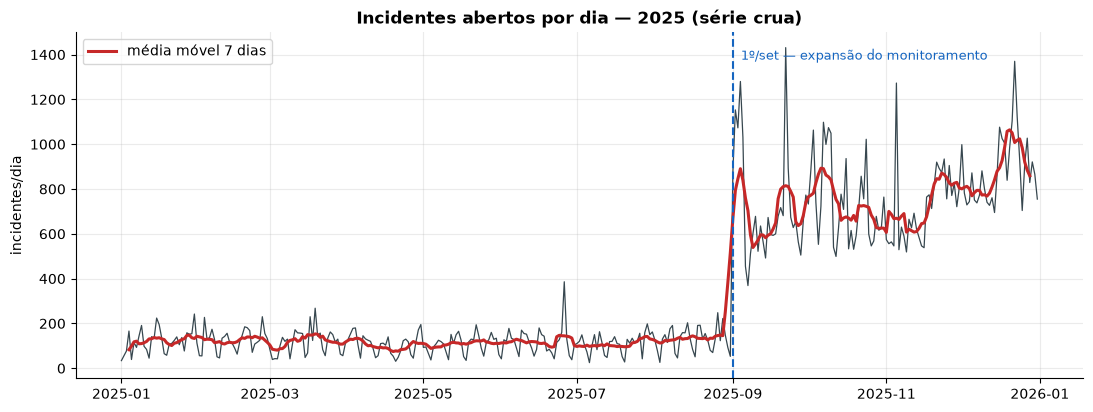

jan-ago :  116.8 incidentes/dia
set-dez :  765.8 incidentes/dia
salto   : 6.6x


In [5]:
idx25 = pd.date_range("2025-01-01", "2025-12-31")
serie_crua = d25.groupby("dia").size().reindex(idx25, fill_value=0)
corte = pd.Timestamp("2025-09-01")

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(serie_crua.index, serie_crua.values, lw=.9, color="#37474f")
ax.plot(serie_crua.index, serie_crua.rolling(7, center=True).mean(), lw=2.2, color="#c62828",
        label="média móvel 7 dias")
ax.axvline(corte, color="#1565c0", ls="--", lw=1.5)
ax.text(corte, ax.get_ylim()[1]*.95, "  1º/set — expansão do monitoramento",
        color="#1565c0", va="top", fontsize=9)
ax.set_title("Incidentes abertos por dia — 2025 (série crua)", fontweight="bold")
ax.set_ylabel("incidentes/dia"); ax.legend(); plt.show()

antes  = serie_crua[serie_crua.index <  corte].mean()
depois = serie_crua[serie_crua.index >= corte].mean()
print(f"jan-ago : {antes:6.1f} incidentes/dia")
print(f"set-dez : {depois:6.1f} incidentes/dia")
print(f"salto   : {depois/antes:.1f}x")

Um salto de ~7× de um dia para o outro. **A pergunta que decide todo o projeto:** a operação
piorou, ou só passamos a enxergar mais?

Para responder, decompomos o salto **por origem do incidente**.

In [6]:
def taxa(mask, label):
    s = d25[mask].groupby("dia").size().reindex(idx25, fill_value=0)
    a, b = s[s.index < corte].mean(), s[s.index >= corte].mean()
    return {"recorte": label, "jan-ago/dia": round(a, 1), "set-dez/dia": round(b, 1),
            "razao": round(b/a, 2) if a > 0 else np.nan}

linhas = [
    taxa(d25["Aberto por"].eq("Manual"),        "Aberto por Manual"),
    taxa(d25["Aberto por"].eq("Monitoramento"), "Aberto por Monitoramento"),
    taxa(d25["Entrou para KPI?"].eq("SIM"),     "Elegivel a KPI"),
    taxa(pd.Series(True, index=d25.index),      "TOTAL"),
]
print(pd.DataFrame(linhas).to_string(index=False))

cis_ago = d25[d25["dia"].dt.month == 8]["Item de configuração"].nunique()
cis_set = d25[d25["dia"].dt.month == 9]["Item de configuração"].nunique()
print(f"\nCIs (ativos monitorados) distintos: agosto {cis_ago:,} -> setembro {cis_set:,} "
      f"(+{cis_set-cis_ago:,})")

                 recorte  jan-ago/dia  set-dez/dia  razao
       Aberto por Manual         52.7         40.2   0.76
Aberto por Monitoramento         64.1        725.6  11.31
          Elegivel a KPI         72.6         61.5   0.85
                   TOTAL        116.8        765.8   6.55

CIs (ativos monitorados) distintos: agosto 1,206 -> setembro 3,045 (+1,839)


**O veredito está na tabela:**

- Aberturas **manuais caíram** (razão < 1) — não há mais gente abrindo chamado.
- Aberturas por **monitoramento explodiram** (~11×).
- A carga **elegível a KPI ficou estável** (razão < 1) — o que o negócio mede não aumentou.
- Entraram ~1.700 **CIs novos** em setembro.

> 💡 **Insight de pitch:** o volume bruto multiplicou por ~7, mas a **carga operacional real
> ficou estável**. Quem olhar só o gráfico conclui "a operação está afundando" — e erra. O dado
> apenas ganhou visibilidade.

**Consequência metodológica:** são dois mundos. O modelo **treina** com os dois (testamos isso no
Experimento 4), mas a **nota** só pode sair no mundo em que ele vai operar (~750/dia). Medir
acerto em jan–ago daria um erro absoluto pequeno só porque o volume era pequeno.

---
## 4. Os picos são cascatas, não crises

Quando um ativo cai, o monitoramento não abre 1 incidente: abre **1 pai + dezenas ou centenas de
filhos** (cada serviço afetado vira um alarme). A coluna `Incidente Pai` marca quem é filho.

Vamos abrir o maior pico do P2 no ano, linha a linha.

In [7]:
p2 = d25[d25["_prio"].eq(2)]
pico = p2.groupby("dia").size().idxmax()

sub    = p2[p2["dia"].eq(pico)]
filhos = sub["Incidente Pai"].notna().sum()
maior  = sub.loc[sub["Incidente Pai"].notna(), "Incidente Pai"].value_counts()

print(f"Dia de pico do P2 : {pico.date()}")
print(f"  total no dia     : {len(sub)}")
print(f"  eram filhos      : {filhos} ({100*filhos/len(sub):.0f}%)")
print(f"  maior cascata    : 1 unico incidente-pai gerou {maior.iloc[0]} filhos")
print(f"  eventos-RAIZ     : {len(sub)-filhos}   <- o numero real de problemas do dia")

Dia de pico do P2 : 2025-11-05
  total no dia     : 684
  eram filhos      : 620 (91%)
  maior cascata    : 1 unico incidente-pai gerou 510 filhos
  eventos-RAIZ     : 64   <- o numero real de problemas do dia


### Decisão de limpeza nº 2 — deduplicar cascatas

Ficamos apenas com os incidentes **sem pai** (os "raiz"). Ou seja: **contar eventos, não alarmes.**

**Por que isso é legítimo e não "jogar dado fora":** o próprio dicionário de dados diz que
*incidente com `Incidente Pai` preenchido não entra no KPI*. Deduplicar é contar exatamente o
que o negócio já mede. Um pico de centenas de alarmes não é centenas de problemas — é **um**
problema.

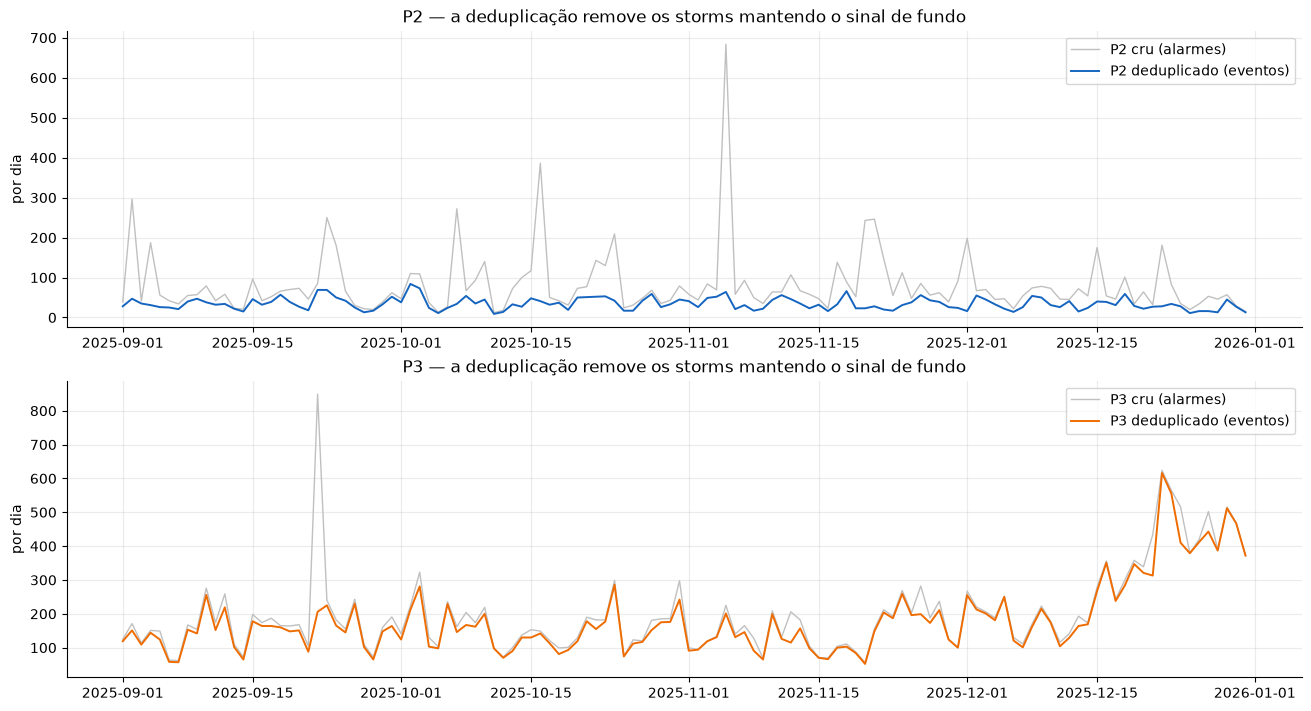

In [8]:
dedup = d25[d25["Incidente Pai"].isna()]

def diaria(frame, prio=None):
    f = frame if prio is None else frame[frame["_prio"].eq(prio)]
    return f.groupby("dia").size().reindex(idx25, fill_value=0).astype(float)

sl = slice("2025-09-01", "2025-12-31")
fig, axes = plt.subplots(2, 1, figsize=(13, 7), constrained_layout=True)
for ax, p, cor in zip(axes, [2, 3], ["#1565c0", "#ef6c00"]):
    ax.plot(diaria(d25, p)[sl].index,   diaria(d25, p)[sl].values,   lw=1,
            color="#c0c0c0", label=f"P{p} cru (alarmes)")
    ax.plot(diaria(dedup, p)[sl].index, diaria(dedup, p)[sl].values, lw=1.4,
            color=cor, label=f"P{p} deduplicado (eventos)")
    ax.set_title(f"P{p} — a deduplicação remove os storms mantendo o sinal de fundo")
    ax.set_ylabel("por dia"); ax.legend()
plt.show()

In [9]:
def acf(s, k):
    s = np.asarray(s, float)
    return np.corrcoef(s[:-k], s[k:])[0, 1] if s.std() > 0 else np.nan

linhas = []
for p in [2, 3]:
    for frame, tag in [(d25, "cru"), (dedup, "dedup")]:
        s = diaria(frame, p)[sl]
        linhas.append({"serie": f"P{p} {tag}", "max/dia": int(s.max()),
                       "cv": round(s.std()/s.mean(), 2), "acf1": round(acf(s, 1), 2)})
print(pd.DataFrame(linhas).to_string(index=False))

   serie  max/dia   cv  acf1
  P2 cru      684 1.01  0.05
P2 dedup       84 0.44  0.32
  P3 cru      849 0.62  0.57
P3 dedup      616 0.58  0.76


**Leia a coluna `acf1`** — ela mede o quanto o dia de hoje ajuda a prever o de amanhã.

No P2 ela salta de ~0,05 (praticamente nada: série imprevisível) para ~0,32. E o `cv`
(irregularidade) cai pela metade.

> A deduplicação **não melhorou o modelo — ela revelou o sinal que os alarmes escondiam.**

---
## 5. Cada prioridade é um bicho diferente

Por isso treinamos **uma série por prioridade** em vez de um modelo único: elas não se parecem.

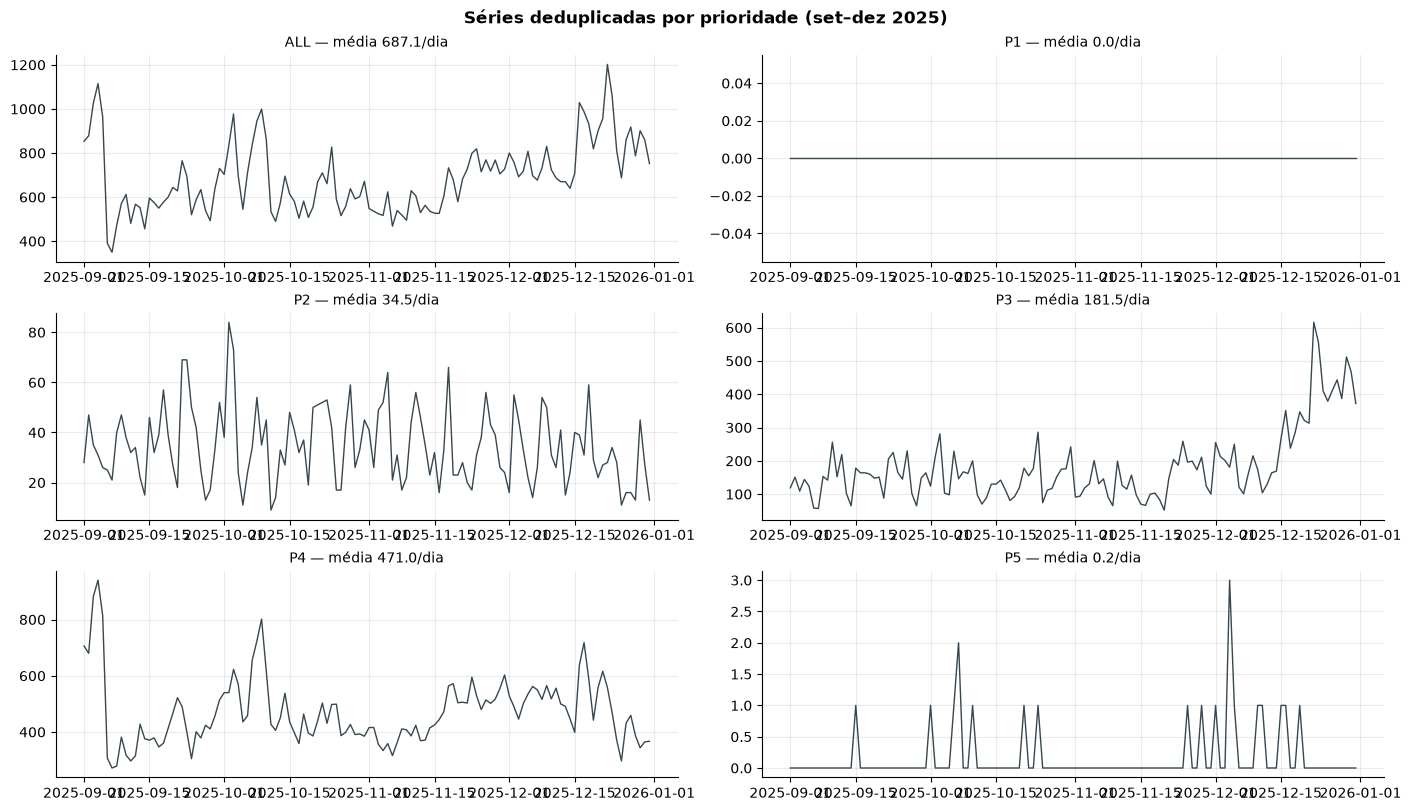

In [10]:
series = {"ALL": diaria(dedup)}
for p in [1, 2, 3, 4, 5]:
    series[f"P{p}"] = diaria(dedup, p)

fig, axes = plt.subplots(3, 2, figsize=(14, 8), constrained_layout=True)
for ax, (nome, s) in zip(axes.ravel(), series.items()):
    ax.plot(s[sl].index, s[sl].values, lw=1, color="#37474f")
    ax.set_title(f"{nome} — média {s[sl].mean():.1f}/dia", fontsize=10)
fig.suptitle("Séries deduplicadas por prioridade (set–dez 2025)", fontweight="bold")
plt.show()

Média por dia da semana:

       seg    ter    qua    qui    sex    sáb    dom  fds/útil
ALL  702.2  744.3  713.2  693.7  723.0  631.8  595.8       0.9
P2    39.2   46.4   39.8   38.8   34.7   22.2   19.2       0.5
P3   213.8  211.7  191.1  172.4  210.8  141.1  125.3       0.7
P4   449.1  485.9  482.2  482.3  477.2  468.5  451.3       1.0


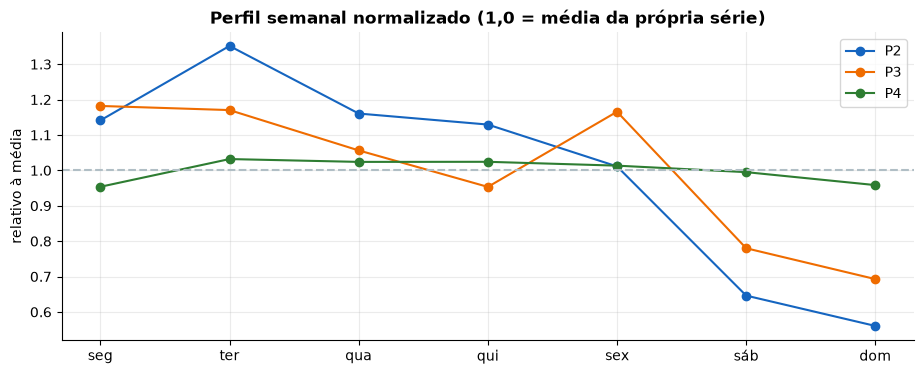

In [11]:
dias = ["seg", "ter", "qua", "qui", "sex", "sáb", "dom"]
perfil = {}
for nome in ["ALL", "P2", "P3", "P4"]:
    s = series[nome][sl]
    g = s.groupby(s.index.dayofweek).mean()
    perfil[nome] = [g.get(k, np.nan) for k in range(7)]
P = pd.DataFrame(perfil, index=dias).T
P["fds/útil"] = (P[["sáb", "dom"]].mean(axis=1)
                 / P[["seg", "ter", "qua", "qui", "sex"]].mean(axis=1)).round(2)
print("Média por dia da semana:\n")
print(P.round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 4))
for nome, cor in [("P2", "#1565c0"), ("P3", "#ef6c00"), ("P4", "#2e7d32")]:
    v = P.loc[nome, dias].astype(float)
    ax.plot(dias, v/v.mean(), marker="o", color=cor, label=nome)
ax.axhline(1, color="#b0bec5", ls="--")
ax.set_title("Perfil semanal normalizado (1,0 = média da própria série)", fontweight="bold")
ax.set_ylabel("relativo à média"); ax.legend(); plt.show()

In [12]:
linhas = []
for nome in ["ALL", "P2", "P3", "P4", "P5"]:
    y     = series[nome][sl]
    tend  = y.rolling(7, center=True).mean()
    detr  = y - tend
    saz   = detr.groupby(detr.index.dayofweek).transform("mean")
    resid = (detr - saz).dropna()
    vr    = float(np.var(resid))
    Fsaz  = max(0.0, 1 - vr/max(1e-9, float(np.var(saz.reindex(resid.index) + resid))))
    Ftend = max(0.0, 1 - vr/max(1e-9, float(np.var(tend.reindex(resid.index) + resid))))
    linhas.append({"serie": nome, "media/dia": round(y.mean(), 1),
                   "cv": round(y.std()/y.mean(), 2), "var/media": round(y.var()/y.mean(), 1),
                   "F_sazonal": round(Fsaz, 2), "F_tendencia": round(Ftend, 2),
                   "acf1": round(acf(y, 1), 2), "acf7": round(acf(y, 7), 2)})
print(pd.DataFrame(linhas).to_string(index=False))

serie  media/dia   cv  var/media  F_sazonal  F_tendencia  acf1  acf7
  ALL      687.1 0.23       37.5       0.22         0.63  0.73  0.37
   P2       34.5 0.44        6.6       0.46         0.24  0.32  0.36
   P3      181.5 0.58       61.5       0.41         0.82  0.76  0.67
   P4      471.0 0.26       30.6       0.03         0.54  0.75 -0.00
   P5        0.2 2.76        1.2       0.09         0.23  0.15  0.02


**Como ler:** `F_sazonal` e `F_tendencia` vão de 0 (não existe) a 1 (domina). `var/media` seria
**1** se fosse contagem pura (Poisson) — acima disso indica surtos. `acf7` mede o quanto o mesmo
dia da semana passada ajuda a prever.

**O que os números ensinam:**

- **P2 é humana** — cai ~metade no fim de semana e tem a maior força sazonal. Segue horário comercial.
- **P4 é máquina** — força sazonal ~0,03 e `acf7` ~0,00: totalmente plana, roda 24/7, **não sabe
  que é domingo**.
- **P3 é a mais volátil** e a que mais anda de nível (tendência alta).
- **Todas são fortemente superdispersas** (`var/media` de 30 a 60 contra 1 do Poisson): boa parte
  do movimento é **surto genuinamente imprevisível**. Esse é o teto de acerto.
- **P5 é intermitente** (quase sempre 0) e **P1 teve ~1 evento no ano** — não há série.

> ⚠️ **A descoberta que mudou toda a avaliação:** como o **P4 não tem sazonalidade semanal**,
> comparar o modelo contra a régua "mesmo dia da semana passada" ali é competir contra um
> espantalho. É o Experimento 1 da seção 9.

---
## 6. Como o modelo aprende

Transformamos previsão de série temporal em **regressão supervisionada**: uma linha por dia, a
resposta é o valor de D+1 (ou D+7), e as perguntas são pistas conhecidas de antemão.

| Grupo de features | Quais |
|---|---|
| Calendário (determinístico) | dia da semana, fim de semana, feriado BR, Black Friday, temporada de dezembro |
| Histórico | mesmo dia semana passada, último valor, média/desvio dos últimos 7 e 28 dias |
| Exposição | nº de CIs ativos — é o que "atravessa" a quebra de regime |
| Tendência | contador de tempo |

**Antivazamento (*data leakage*) — regra inegociável:**
- Split **temporal**: passado treina, futuro testa. **Nunca** aleatório.
- Toda feature de histórico leva `shift(h)`: ao prever D+7, o modelo só vê o que se sabia 7 dias antes.
- Calendário do dia-alvo **pode** ser usado (é determinístico — sabemos hoje que 25/12 é feriado).
- **Proibido** derivar qualquer coisa de `Resolvido`, `Encerrado`, `Duração`, `Código de fechamento`
  — isso só existe *depois* que o incidente acabou.

---
## 7. A escada de algoritmos

Só pagamos complexidade (e perda de interpretabilidade) quando ela compra acerto.

| Degrau | Preditor | Como funciona | Por que está aqui |
|---|---|---|---|
| 0 | `naive7` | mesmo dia da semana passada | régua para série com ciclo semanal |
| 0 | `media7` | média dos últimos 7 dias conhecidos | régua para série **sem** ciclo semanal |
| 0 | `ultimo` | repete o último valor conhecido | régua de persistência; imbatível em série lisa |
| 1 | **Ridge** | linear com regularização | o **interpretável** — dá para ler o peso de cada pista |
| 2 | **Poisson-offset** | modela a *taxa* por CI ativo | família correta para **contagem**; nunca prevê negativo |
| 3 | **GBR** | boosting com perda Poisson | capta não-linearidade; mede o teto. Caixa-preta |

### O que descartamos, e por quê

- **LSTM / redes neurais:** só ~120 dias de regime pleno. Rede neural com esse volume **decora**
  e não é interpretável. Canhão para matar mosca. *(ANN faz sentido na frente de risco, onde o
  problema é outro.)*
- **ARIMA / Prophet como carro-chefe:** bons em série temporal, mas absorvem pior as features
  externas (exposição de CIs, Black Friday) e entregam menos interpretabilidade por variável.
- **Poisson simples (sem offset):** **testado e falhou** — o link logarítmico ficou instável na
  quebra de regime (P2 D+1 chegou a **−102%** de skill, muito pior que a régua boba). Substituído
  pelo Poisson-offset, que resolveu. Erro registrado de propósito.

### 7.1 Resumo das features: utilidade, vantagem e limitação

| Feature / grupo | Utilidade | Vantagem | Limitação |
|---|---|---|---|
| `seas_lag7`, `seas_lag14` | Captar repetição semanal | Simples e fácil de interpretar | Perde força quando a série não tem sazonalidade semanal |
| `last` | Representar o nível mais recente conhecido | Reage rápido a mudanças | Pode carregar ruído de um único dia |
| `roll7_mean` | Nível médio recente | Suaviza oscilações pontuais | Responde com atraso a mudanças bruscas |
| `roll7_std` | Volatilidade recente | Diferencia períodos estáveis e turbulentos | Pode ficar instável em janelas curtas |
| `roll28_mean` | Patamar mensal aproximado | Mais robusta a picos isolados | Reage mais lentamente a quebras de regime |
| `exp_last`, `exp_roll7` | Medir exposição por CIs ativos | Ajuda a separar carga monitorada de taxa de incidentes | Depende da qualidade do campo de configuração |
| `r_last`, `r_roll7`, `r_seas7` | Incidentes por unidade de exposição | Úteis no modelo de taxa/Poisson | Ficam sensíveis quando a exposição é muito baixa |
| `trend` | Captar evolução ao longo do ano | Representação simples de tendência | Não representa sozinho mudanças abruptas |
| `dow_*`, `is_weekend`, `is_holiday` | Captar calendário operacional | Conhecidas no momento da previsão, sem leakage | O efeito pode mudar entre prioridades |
| `black_week`, `dec_season` | Captar períodos especiais | Introduz contexto de negócio conhecido previamente | São regras específicas do calendário adotado |

---
## 8. Motor de previsão incorporado ao notebook

Para a aplicação do projeto, a lógica continua mantida em `pipeline_prioridades.py`. Nesta versão
acadêmica, porém, o mesmo código é incorporado diretamente ao notebook para que a entrega seja um
**arquivo único executável**.

Não há mudança na regra de features, nos candidatos, no walk-forward, na seleção em set–out nem na
avaliação em nov–dez. A única adaptação é a resolução dos caminhos dos arquivos ao ambiente do notebook.

⏱️ Esta etapa executa o pipeline completo e pode levar alguns minutos.

In [13]:
# -*- coding: utf-8 -*-
"""
Albus Hub - Frente ML (Integrante 2) - Pipeline v3.2: VOLUME por PRIORIDADE, DEDUPLICADO.

HISTORICO
  v3   - serie deduplicada (so incidentes-raiz) + um modelo por prioridade.
  v3.1 - intervalo conformal adaptativo (faixa que se ajusta sozinha).
  v3.2 - HONESTIDADE METODOLOGICA (esta versao). Tres correcoes:
    (1) BASELINE JUSTO. Antes comparavamos so com "naive7" (mesmo dia da semana passada).
        Descobrimos que em series SEM sazonalidade semanal (P4: forca sazonal 0,03) essa
        regua e um espantalho. Agora concorremos contra a MELHOR de tres reguas bobas:
        naive7, media7 (media dos ultimos 7 dias) e ultimo (repete o valor conhecido).
    (2) JANELA DE TREINO TESTADA. Hipotese: treinar so no regime pleno (Set-Dez) seria
        melhor. FALSA - o Ridge PIORA 21-24% com menos dados. Mantemos o ano inteiro.
    (3) PREDITOR FIXADO A PRIORI. Antes o codigo escolhia o vencedor olhando o proprio
        teste (viesado). Agora escolhe em SET-OUT e reporta em NOV-DEZ. As reguas bobas
        SAO CANDIDATAS de pleno direito e vale a regra de Occam ao longo da escada de
        complexidade: fica o preditor mais SIMPLES que chega a 5% do melhor.

PROTOCOLO
  walk-forward diario | selecao: set-out/2025 (61d) | nota: nov-dez/2025 (61d nunca vistos)
Le o dataset bruto (fonte de verdade); cacheia parquet local.
"""
import os, json, warnings
import numpy as np, pandas as pd, holidays
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
from sklearn.linear_model import PoissonRegressor, Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
warnings.filterwarnings("ignore")

HERE = ML
SRC = os.path.join(os.path.dirname(ML), "Dados", "LW-DATASET.xlsx")
CACHE = os.path.join(ML, "data", "incidents.parquet")
OUT = os.path.join(ML, "outputs"); PLOTS = os.path.join(ML, "plots")
for d in (os.path.dirname(CACHE), OUT, PLOTS): os.makedirs(d, exist_ok=True)
MODEL_VERSION = "volume_v3.2_2026-08-21"

# ---------------------------------------------------------------- 1. DADOS
if os.path.exists(CACHE): df = pd.read_parquet(CACHE)
else:
    df = pd.read_excel(SRC, sheet_name="Dataset Geral"); df.to_parquet(CACHE, index=False)
df["_prio"]=df["Prioridade"].str.extract(r"^\s*(\d)").astype("Int64")
df["Aberto"]=pd.to_datetime(df["Aberto"]); df["dia"]=df["Aberto"].dt.floor("D")
d25 = df[df["Aberto"].dt.year==2025].copy()
dedup = d25[d25["Incidente Pai"].isna()]          # <- DEDUPLICACAO (so raiz)

LAST=pd.Timestamp("2025-12-31"); idx=pd.date_range("2025-01-01",LAST+pd.Timedelta(days=7),freq="D")
def daily(frame, mask=None):
    f = frame if mask is None else frame[mask]
    s = f.groupby("dia").size().reindex(idx); s.loc[:LAST]=s.loc[:LAST].fillna(0); return s
series = {"ALL": daily(dedup)}
for p in [1,2,3,4,5]: series[f"P{p}"] = daily(dedup, dedup["_prio"].eq(p))
active_cis = d25.groupby("dia")["Item de configuração"].nunique().reindex(idx)
active_cis.loc[:LAST]=active_cis.loc[:LAST].fillna(0); active_cis=active_cis.ffill()

# ---------------------------------------------------------- 2. CALENDARIO
br=holidays.Brazil(years=[2025,2026]); BF=pd.Timestamp("2025-11-28")
def calfeat(dates):
    c=pd.DataFrame(index=dates); dow=dates.dayofweek
    for k in range(7): c[f"dow_{k}"]=(dow==k).astype(int)
    c["is_weekend"]=(dow>=5).astype(int)
    c["is_holiday"]=[1 if x in br else 0 for x in dates]
    c["black_week"]=[1 if BF-pd.Timedelta(days=1)<=x<=BF+pd.Timedelta(days=4) else 0 for x in dates]
    c["dec_season"]=((dates.month==12)&(dates.day>=15)).astype(int)
    return c
CAL=calfeat(idx); CALCOLS=list(CAL.columns)

# --------------------------------------------- 3. FEATURES (sem vazamento)
def build_Xy(y,h):
    ys=y.shift(h); X=pd.DataFrame(index=y.index)
    X["seas_lag7"]=y.shift(7); X["seas_lag14"]=y.shift(14); X["last"]=ys
    X["roll7_mean"]=ys.rolling(7).mean(); X["roll7_std"]=ys.rolling(7).std(); X["roll28_mean"]=ys.rolling(28).mean()
    X["exp_last"]=active_cis.shift(h); X["exp_roll7"]=active_cis.shift(h).rolling(7).mean()
    X["trend"]=np.arange(len(y))
    ex=X["exp_roll7"].replace(0,np.nan); exl=X["exp_last"].replace(0,np.nan)
    X["r_last"]=X["last"]/exl; X["r_roll7"]=X["roll7_mean"]/ex; X["r_seas7"]=X["seas_lag7"]/ex
    return X.join(CAL), y
FEATS_LEVEL=["seas_lag7","seas_lag14","last","roll7_mean","roll7_std","roll28_mean","exp_last","exp_roll7","trend"]+CALCOLS
FEATS_RATE =["r_last","r_roll7","r_seas7"]+CALCOLS
ALLF=list(dict.fromkeys(FEATS_LEVEL+FEATS_RATE))

# REGUAS BOBAS (candidatas de pleno direito) e MODELOS
BASES  = ["naive7","media7","ultimo"]         # simples: sem treino, so aritmetica do passado
LEARNED= ["ridge","poisson_off","gbr"]        # aprendidos
CANDS  = BASES + LEARNED
# escada de complexidade, do mais simples ao mais complexo (usada na regra de Occam):
# regua boba < linear interpretavel < contagem interpretavel < caixa-preta
ORDER  = ["naive7","media7","ultimo","ridge","poisson_off","gbr"]
def base_series(y,h):
    """As tres reguas bobas, ja com o shift correto para o horizonte h."""
    return {"naive7": y.shift(7),                       # mesmo dia da semana passada
            "media7": y.shift(h).rolling(7).mean(),     # media dos ultimos 7 dias conhecidos
            "ultimo": y.shift(h)}                       # repete o ultimo valor conhecido
def fit_pred(name,Xtr,ytr,xrow):
    if len(ytr)==0: return 0.0
    if ytr.nunique()<=1: return float(ytr.iloc[0])      # serie constante (ex.: P1)
    if name=="poisson_off":
        expo=Xtr["exp_roll7"].clip(lower=1e-6); rate=ytr/expo
        if rate.sum()==0: return 0.0
        m=make_pipeline(StandardScaler(),PoissonRegressor(alpha=1e-4,max_iter=6000))
        m.fit(Xtr[FEATS_RATE],rate,poissonregressor__sample_weight=expo.values)
        return max(0.0,float(m.predict(xrow[FEATS_RATE])[0])*max(1e-6,float(xrow["exp_roll7"].iloc[0])))
    m=(make_pipeline(StandardScaler(),Ridge(alpha=5.0)) if name=="ridge"
       else HistGradientBoostingRegressor(loss="poisson",max_depth=3,learning_rate=0.08,
                                          max_iter=250,min_samples_leaf=15,random_state=0))
    m.fit(Xtr[FEATS_LEVEL],ytr); return max(0.0,float(m.predict(xrow[FEATS_LEVEL])[0]))

def smape(a,p): a,p=np.asarray(a,float),np.asarray(p,float); return float(100*np.mean(2*np.abs(a-p)/(np.abs(a)+np.abs(p)+1e-9)))
def mae(a,p): return float(np.mean(np.abs(np.asarray(a,float)-np.asarray(p,float))))
def mets(a,p): a,p=np.asarray(a,float),np.asarray(p,float); return {"MAE":mae(a,p),"RMSE":float(np.sqrt(np.mean((a-p)**2))),"sMAPE":smape(a,p),"n":int(len(a))}

# ------------------------------------- 3b. INTERVALO CONFORMAL ADAPTATIVO (v3.1)
# Largura proporcional a sqrt(previsto) (escala de contagem) + auto-correcao diaria do
# alpha (ACI): caiu fora -> alarga amanha; sobrou folga -> aperta. So residuos passados.
ALPHA=0.20; BURN=28; WIN=60; GAMMA=0.03
def _s(x): return max(1.0, float(np.sqrt(max(float(x),0.0))))
def bands(a,p):
    n=len(a); lo=np.full(n,np.nan); hi=np.full(n,np.nan); sc=[]; at=ALPHA; qlo=qhi=0.0
    for i in range(n):
        if i>=BURN:
            ps=np.array(sc[-WIN:])
            qlo=float(np.quantile(ps,at/2)); qhi=float(np.quantile(ps,1-at/2))
            lo[i]=max(0.0,p[i]+qlo*_s(p[i])); hi[i]=p[i]+qhi*_s(p[i])
            at=float(np.clip(at+GAMMA*(ALPHA-(0.0 if lo[i]<=a[i]<=hi[i] else 1.0)),0.01,0.60))
        sc.append((a[i]-p[i])/_s(p[i]))
    ev=np.zeros(n,bool); ev[BURN:]=True
    return lo,hi,ev,(qlo,qhi)
def _bf(v,p):
    v=np.asarray(v,float).copy(); ok=np.flatnonzero(~np.isnan(v))
    if len(ok)==0: return np.asarray(p,float).copy()
    v[:ok[0]]=v[ok[0]]; return v

# ---------------------------- 4. WALK-FORWARD + SELECAO HONESTA + PREVISAO
EVAL0=pd.Timestamp("2025-09-01")    # comeco do walk-forward (inicio do regime pleno)
SELEND=pd.Timestamp("2025-10-31")   # SET+OUT (61d): so para escolher e aquecer o conformal.
                                    # 1 mes so era ruidoso demais e escolhia mal; 2 meses estabiliza.
REP0=pd.Timestamp("2025-11-01")     # daqui em diante: a nota (61 dias, nunca vistos na escolha)
TIEBREAK=0.05                       # se a regua boba chega a 5% do melhor, fica a regua (Occam)

all_metrics={}; all_preds=[]; chosen={}
for scope,y in series.items():
    all_metrics[scope]={}
    for h,hn in [(1,"D+1"),(7,"D+7")]:
        X,yt=build_Xy(y,h); ok=X[ALLF].notna().all(axis=1) & yt.notna() & (yt.index<=LAST)
        B=base_series(y,h); td=yt.index[ok & (yt.index>=EVAL0)]
        preds={c:[] for c in CANDS}
        for d in td:
            tr=ok & (yt.index<d); Xtr,ytr,xr=X.loc[tr],yt.loc[tr],X.loc[[d]]
            for c in BASES:   preds[c].append(max(0.0,float(B[c].loc[d])))
            for c in LEARNED: preds[c].append(fit_pred(c,Xtr,ytr,xr))
        a=yt.loc[td].values; Pm={c:np.array(preds[c]) for c in CANDS}
        sel=td<=SELEND; rep=td>=REP0

        # --- (3) escolha do preditor: SO com set-out. Regra de Occam ao longo da escada de
        # complexidade (ORDER): fica o PRIMEIRO candidato que chega a 5% do melhor. Assim
        # so pagamos complexidade (e perda de interpretabilidade) quando ela compra acerto.
        msel={c:mae(a[sel],Pm[c][sel]) for c in CANDS}
        floor_=min(msel.values())
        pick=next(c for c in ORDER if msel[c] <= floor_*(1+TIEBREAK))
        chosen[(scope,hn)]=pick

        # --- (1) nota em nov-dez contra a MELHOR regua boba (medida no proprio periodo)
        mrep={c:mae(a[rep],Pm[c][rep]) for c in CANDS}
        base_ref=min(BASES,key=lambda c: mrep[c])
        m=mets(a[rep],Pm[pick][rep])
        m["skill_vs_melhor_regua"]=float(1-mrep[pick]/mrep[base_ref]) if mrep[base_ref]>1e-9 else float("nan")
        m["skill_vs_naive7"]      =float(1-mrep[pick]/mrep["naive7"]) if mrep["naive7"]>1e-9 else float("nan")
        all_metrics[scope][hn]={"_escolhido":pick,"_tipo":("regua simples" if pick in BASES else "modelo"),
            "_regua_referencia":base_ref,"_mae_candidatos_nov_dez":{c:round(mrep[c],2) for c in CANDS},
            "_mae_candidatos_out":{c:round(msel[c],2) for c in CANDS}, **m}

        # --- intervalo conformal sobre o preditor escolhido
        bp=Pm[pick]; lo,hi,ev,(qlo,qhi)=bands(a,bp)
        evr=ev & rep
        all_metrics[scope][hn]["_coverage"]={"nominal":.8,
            "conformal_nov_dez":float(np.mean((a[evr]>=lo[evr])&(a[evr]<=hi[evr]))) if evr.any() else float("nan"),
            "largura_media":float(np.nanmean(hi[evr]-lo[evr])) if evr.any() else float("nan"),
            "n_avaliado":int(evr.sum())}
        LO,HI=_bf(lo,bp),_bf(hi,bp)
        for dte,av,pv,l_,h_ in zip(td,a,bp,LO,HI):
            all_preds.append(dict(reference_date=dte.date(),horizon=hn,scope=scope,predicted_incidents=int(round(pv)),
                actual_incidents=int(av),lower_bound=max(0,int(round(l_))),upper_bound=int(round(max(h_,l_))),
                model=pick,model_version=MODEL_VERSION))
        # --- previsao futura com o preditor escolhido
        fut=LAST+pd.Timedelta(days=h)
        fp=(max(0.0,float(B[pick].loc[fut])) if pick in BASES
            else fit_pred(pick,X.loc[ok],yt.loc[ok],X.loc[[fut]]))
        fl,fh=max(0.0,fp+qlo*_s(fp)),fp+qhi*_s(fp)
        all_preds.append(dict(reference_date=fut.date(),horizon=hn,scope=scope,predicted_incidents=int(round(fp)),
            actual_incidents=None,lower_bound=max(0,int(round(fl))),upper_bound=int(round(max(fh,fl))),
            model=pick,model_version=MODEL_VERSION))

pred_df=pd.DataFrame(all_preds)
pred_df.to_csv(os.path.join(OUT,"predictions_volume.csv"),index=False)
pred_df.to_parquet(os.path.join(OUT,"predictions_volume.parquet"),index=False)
json.dump(all_metrics,open(os.path.join(OUT,"metrics.json"),"w",encoding="utf-8"),ensure_ascii=False,indent=2,default=str)

# ---------------------------------------------------------- 5. RESUMO
print("="*110)
print("PIPELINE v3.2 - VOLUME por PRIORIDADE, DEDUPLICADO")
print("  escolha do preditor: SET+OUT/2025  |  nota: NOV-DEZ/2025 (61 dias, nao usados na escolha)")
print("  skill = ganho sobre a MELHOR das 3 reguas bobas (naive7 / media7 / ultimo)")
print("="*110)
print(f"{'scope':6}{'hor':5}{'preditor':>13}{'tipo':>16}{'regua':>9}{'MAE':>8}{'sMAPE':>8}"
      f"{'skill':>8}{'(vs naive7)':>13}{'cobert':>8}")
pct=lambda v: "n/a" if not np.isfinite(v) else f"{v*100:+.0f}%"
for scope in series:
    for hn in ["D+1","D+7"]:
        m=all_metrics[scope][hn]; c=m["_coverage"]
        cv="n/a" if not np.isfinite(c["conformal_nov_dez"]) else f"{c['conformal_nov_dez']*100:.0f}%"
        print(f"{scope:6}{hn:5}{m['_escolhido']:>13}{m['_tipo']:>16}{m['_regua_referencia']:>9}"
              f"{m['MAE']:>8.1f}{m['sMAPE']:>7.1f}%{pct(m['skill_vs_melhor_regua']):>8}"
              f"{pct(m['skill_vs_naive7']):>13}{cv:>8}")

n_mod=sum(1 for v in chosen.values() if v in LEARNED)
print(f"\nPreditor escolhido: MODELO em {n_mod}/{len(chosen)} combinacoes; REGUA SIMPLES nas demais.")
print("(entregar a regua simples onde ela ganha e decisao de engenharia, nao fracasso do ML)")

print("\nPREVISAO FUTURA (a partir de 2025-12-31):")
print(pred_df[pred_df.actual_incidents.isna()][["scope","horizon","reference_date",
      "predicted_incidents","lower_bound","upper_bound","model"]].to_string(index=False))

# ---------------------------------------------------------- 6. GRAFICO
plt.rcParams.update({"font.size":10,"axes.grid":True,"grid.alpha":.25,"axes.spines.top":False,"axes.spines.right":False})
show=["ALL","P2","P3","P4"]; fig,ax=plt.subplots(len(show),1,figsize=(14,13),constrained_layout=True)
fig.suptitle("v3.2 — Backtest D+1: previsto vs real + intervalo conformal (nota: Nov–Dez 2025)",fontweight="bold",fontsize=13)
for a_,scope in zip(ax,show):
    sub=pred_df[(pred_df.scope==scope)&(pred_df.horizon=="D+1")&(pred_df.actual_incidents.notna())]
    dts=pd.to_datetime(sub.reference_date)
    a_.plot(dts,sub.actual_incidents,color="#263238",lw=1.3,label="real")
    a_.plot(dts,sub.predicted_incidents,color="#c62828",lw=1.3,ls="--",label="previsto")
    a_.fill_between(dts,sub.lower_bound,sub.upper_bound,color="#c62828",alpha=.15,label="intervalo 80%")
    a_.axvline(REP0,color="#1565c0",lw=1.2,ls=":"); a_.text(REP0,a_.get_ylim()[1],"  início da nota",
        color="#1565c0",va="top",fontsize=8)
    m=all_metrics[scope]["D+1"]
    a_.set_title(f"{scope} — preditor: {m['_escolhido']} ({m['_tipo']}) · MAE {m['MAE']:.1f} · "
                 f"skill {pct(m['skill_vs_melhor_regua'])} vs melhor régua")
    a_.set_ylabel("eventos/dia"); a_.legend(loc="upper left",ncol=3)
fig.savefig(os.path.join(PLOTS,"backtest_v32_D1.png"),dpi=140,bbox_inches="tight")
print("\nSALVOS: outputs/ (predictions_volume.csv/parquet, metrics.json) + plots/backtest_v32_D1.png")

from types import SimpleNamespace

_PL_EXPORTS = ['ALLF', 'BASES', 'CANDS', 'FEATS_LEVEL', 'LAST', 'LEARNED', 'ORDER', 'SELEND', 'all_metrics', 'base_series', 'build_Xy', 'fit_pred', 'series']
_pl_missing = [name for name in _PL_EXPORTS if name not in globals()]
if _pl_missing:
    raise RuntimeError(f"Objetos esperados do pipeline não foram definidos: {_pl_missing}")

pl = SimpleNamespace(**{name: globals()[name] for name in _PL_EXPORTS})

# O pipeline usa backend Agg para salvar o PNG. Reativamos o backend inline do notebook.
try:
    matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass


PIPELINE v3.2 - VOLUME por PRIORIDADE, DEDUPLICADO
  escolha do preditor: SET+OUT/2025  |  nota: NOV-DEZ/2025 (61 dias, nao usados na escolha)
  skill = ganho sobre a MELHOR das 3 reguas bobas (naive7 / media7 / ultimo)
scope hor       preditor            tipo    regua     MAE   sMAPE   skill  (vs naive7)  cobert
ALL   D+1         ultimo   regua simples   media7    76.6   10.3%     -4%         +27%     77%
ALL   D+7            gbr          modelo   naive7    91.6   12.7%    +13%         +13%     80%
P1    D+1         naive7   regua simples   naive7     0.0    0.0%     n/a          n/a    100%
P1    D+7         naive7   regua simples   naive7     0.0    0.0%     n/a          n/a    100%
P2    D+1          ridge          modelo   media7     9.8   30.0%    +16%         +23%     79%
P2    D+7            gbr          modelo   media7    10.0   30.9%    +15%         +22%     79%
P3    D+1            gbr          modelo   media7    58.9   29.4%     -7%         +22%     82%
P3    D+7           


SALVOS: outputs/ (predictions_volume.csv/parquet, metrics.json) + plots/backtest_v32_D1.png


### Como as features ficam na prática

Uma espiada na matriz que o modelo realmente vê (série P3, horizonte D+1):

In [14]:
X, y = pl.build_Xy(pl.series["P3"], 1)
cols = ["seas_lag7", "last", "roll7_mean", "roll28_mean", "exp_roll7",
        "dow_0", "is_weekend", "is_holiday"]
amostra = X.loc["2025-11-03":"2025-11-09", cols].copy()
amostra.insert(0, "ALVO (real do dia)", y.loc["2025-11-03":"2025-11-09"])
print("Cada linha = um dia. O ALVO é o que queremos prever; o resto só usa o passado.\n")
print(amostra.round(1).to_string())

Cada linha = um dia. O ALVO é o que queremos prever; o resto só usa o passado.

            ALVO (real do dia)  seas_lag7   last  roll7_mean  roll28_mean  exp_roll7  dow_0  is_weekend  is_holiday
2025-11-03               119.0      117.0   94.0       149.6        142.8      222.3      1           0           0
2025-11-04               131.0      152.0  119.0       149.9        138.9      225.1      0           0           0
2025-11-05               201.0      175.0  131.0       146.9        138.4      219.0      0           0           0
2025-11-06               131.0      176.0  201.0       150.6        139.6      301.1      0           0           0
2025-11-07               146.0      242.0  131.0       144.1        138.5      295.0      0           0           0
2025-11-08                91.0       91.0  146.0       130.4        136.5      289.4      0           1           0
2025-11-09                65.0       94.0   91.0       130.4        136.3      289.0      0           1     

### 8.1 Correlação entre as variáveis

A autocorrelação temporal já foi investigada na EDA. Aqui complementamos a análise com a correlação
entre as features numéricas e o alvo, usando P3 D+1 como exemplo. A correlação é **descritiva**:
não é usada para escolher features olhando o período de teste e, portanto, não altera o pipeline.

Valores altos entre lags e médias móveis são esperados porque essas variáveis descrevem versões
diferentes do nível recente da mesma série.

In [15]:
X_corr, y_corr = pl.build_Xy(pl.series["P3"], 1)
corr_frame = X_corr[pl.FEATS_LEVEL].copy()
corr_frame["target"] = y_corr
corr_frame = corr_frame.dropna()

correlacao_target = (
    corr_frame.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename("correlacao_com_target")
)
display(correlacao_target.to_frame().round(3))

top_corr_cols = correlacao_target.head(8).index.tolist() + ["target"]
display(corr_frame[top_corr_cols].corr().round(2))

,correlacao_com_target
roll7_mean,0.861
last,0.840
seas_lag7,0.819
roll28_mean,0.815
dec_season,0.749
roll7_std,0.725
exp_roll7,0.704
seas_lag14,0.688
trend,0.626
exp_last,0.620


,roll7_mean,last,seas_lag7,roll28_mean,dec_season,roll7_std,exp_roll7,seas_lag14,target
roll7_mean,1.00,0.89,0.85,0.94,0.74,0.85,0.80,0.64,0.86
last,0.89,1.00,0.74,0.83,0.73,0.80,0.71,0.61,0.84
seas_lag7,0.85,0.74,1.00,0.82,0.57,0.67,0.68,0.75,0.82
roll28_mean,0.94,0.83,0.82,1.00,0.64,0.80,0.89,0.75,0.81
dec_season,0.74,0.73,0.57,0.64,1.00,0.59,0.39,0.42,0.75
roll7_std,0.85,0.80,0.67,0.80,0.59,1.00,0.74,0.54,0.72
exp_roll7,0.80,0.71,0.68,0.89,0.39,0.74,1.00,0.70,0.70
seas_lag14,0.64,0.61,0.75,0.75,0.42,0.54,0.70,1.00,0.69
target,0.86,0.84,0.82,0.81,0.75,0.72,0.70,0.69,1.00


### 8.2 Modelo simples e interpretável: pesos do Ridge

A rubrica pede um modelo simples para avaliar o impacto potencial das features. Como o pipeline já
inclui Ridge, usamos P2 D+1 — combinação em que o Ridge foi selecionado — para inspecionar seus
coeficientes.

O ajuste abaixo é **somente interpretativo**. Ele usa dados disponíveis até o fim da janela de seleção
e não substitui nem reconfigura o modelo responsável pelas previsões finais. Como há `StandardScaler`,
os coeficientes podem ser comparados em magnitude: sinal positivo indica associação com aumento da
previsão e sinal negativo com redução, mantendo as demais variáveis constantes.

In [16]:
X_ridge, y_ridge = pl.build_Xy(pl.series["P2"], 1)
mask_ridge = (
    X_ridge[pl.FEATS_LEVEL].notna().all(axis=1)
    & y_ridge.notna()
    & (y_ridge.index <= pl.SELEND)
)

ridge_interpretavel = make_pipeline(StandardScaler(), Ridge(alpha=5.0))
ridge_interpretavel.fit(
    X_ridge.loc[mask_ridge, pl.FEATS_LEVEL],
    y_ridge.loc[mask_ridge],
)

coeficientes = pd.Series(
    ridge_interpretavel.named_steps["ridge"].coef_,
    index=pl.FEATS_LEVEL,
    name="coeficiente_padronizado",
)

coef_tabela = (
    coeficientes.to_frame()
    .assign(magnitude=lambda x: x["coeficiente_padronizado"].abs())
    .sort_values("magnitude", ascending=False)
)

display(coef_tabela.head(15).round(3))

print(
    "Leitura: os maiores valores absolutos são as features com maior influência "
    "no Ridge deste recorte. Isso não implica causalidade."
)

,coeficiente_padronizado,magnitude
last,3.513,3.513
exp_roll7,3.048,3.048
seas_lag7,1.816,1.816
exp_last,1.747,1.747
seas_lag14,1.730,1.730
roll7_std,-1.632,1.632
dow_0,1.350,1.350
is_weekend,-1.269,1.269
dow_5,-1.038,1.038
trend,0.690,0.690


Leitura: os maiores valores absolutos são as features com maior influência no Ridge deste recorte. Isso não implica causalidade.


---
# 9. Os experimentos

Esta é a parte que sustenta todas as decisões. Rodamos **5 experimentos** — dois deles
derrubaram coisas em que acreditávamos.

Primeiro construímos uma **tabela mestre**: a previsão diária de **todos os 6 preditores**, para
**todas as séries**, nos **dois horizontes**, com **duas janelas de treino** — tudo em
walk-forward (re-treinando a cada dia, só com o passado). Todos os experimentos são recortes
dessa tabela, então nenhum deles pode discordar do outro.

⏱️ ~10 min na primeira execução; depois lê do cache.

In [17]:
CACHE_WF = os.path.join(ML, "data", "walkforward_experimentos.parquet")
ESCOPOS  = ["ALL", "P2", "P3", "P4"]
REGIMES  = {"ano": pd.Timestamp("2025-01-01"),   # treina desde janeiro
            "set": pd.Timestamp("2025-09-01")}   # treina so no regime pleno
TEST0    = pd.Timestamp("2025-09-01")
INI_SET  = pd.Timestamp("2025-10-01")            # regime 'set' precisa de 1 mes de aquecimento

if os.path.exists(CACHE_WF):
    WF = pd.read_parquet(CACHE_WF)
    print("lido do cache:", CACHE_WF)
else:
    print("calculando (walk-forward, re-treino diario)... isso leva ~10 min\n")
    linhas = []
    for escopo in ESCOPOS:
        yser = pl.series[escopo]
        for h, hn in [(1, "D+1"), (7, "D+7")]:
            Xf, yt = pl.build_Xy(yser, h)
            ok  = Xf[pl.ALLF].notna().all(axis=1) & yt.notna() & (yt.index <= pl.LAST)
            B   = pl.base_series(yser, h)
            for reg, ini in REGIMES.items():
                dias_reg = yt.index[ok & (yt.index >= (TEST0 if reg == "ano" else INI_SET))]
                for d in dias_reg:
                    tr = ok & (yt.index >= ini) & (yt.index < d)
                    r = {"scope": escopo, "horizon": hn, "regime": reg, "date": d,
                         "actual": float(yt.loc[d])}
                    for c in pl.BASES:   r[c] = max(0.0, float(B[c].loc[d]))
                    for c in pl.LEARNED: r[c] = pl.fit_pred(c, Xf.loc[tr], yt.loc[tr], Xf.loc[[d]])
                    linhas.append(r)
            print(f"  ok: {escopo} {hn}")
    WF = pd.DataFrame(linhas)
    WF.to_parquet(CACHE_WF, index=False)
    print("\nsalvo em", CACHE_WF)

WF["date"] = pd.to_datetime(WF["date"])
def mae(a, p): return float(np.mean(np.abs(np.asarray(a, float) - np.asarray(p, float))))
print(f"\ntabela mestre: {len(WF):,} previsoes diarias "
      f"({len(pl.CANDS)} preditores x {WF.scope.nunique()} series x 2 horizontes x 2 janelas)")

calculando (walk-forward, re-treino diario)... isso leva ~10 min



  ok: ALL D+1


  ok: ALL D+7


  ok: P2 D+1


  ok: P2 D+7


  ok: P3 D+1


  ok: P3 D+7


  ok: P4 D+1


  ok: P4 D+7

salvo em /home/bruno/projetos/albus-hub-ml/ml_volume/data/walkforward_experimentos.parquet

tabela mestre: 1,712 previsoes diarias (6 preditores x 4 series x 2 horizontes x 2 janelas)


## Experimento 1 — o baseline estava frouxo?

**Hipótese:** comparar tudo contra `naive7` é injusto nas séries **sem** ciclo semanal (o P4).

**Como testamos:** medimos as três réguas bobas no mesmo período e vemos qual é a mais forte.
Se o `naive7` for muito pior que as outras, todo skill medido contra ele estava inflado.

*(Excluímos as 3 primeiras semanas de setembro, onde o `naive7` ainda está contaminado pelo
degrau de regime — seria bater em cachorro morto.)*

In [18]:
INI = "2025-09-22"
linhas = []
for escopo in ESCOPOS:
    for hn in ["D+1", "D+7"]:
        g = WF[(WF.scope == escopo) & (WF.horizon == hn) & (WF.regime == "ano") & (WF.date >= INI)]
        a = g.actual.values
        mb = {c: mae(a, g[c]) for c in pl.BASES}
        melhor = min(mb, key=mb.get)
        mdl = min(mae(a, g["ridge"]), mae(a, g["gbr"]), mae(a, g["poisson_off"]))
        linhas.append({"serie": escopo, "hor": hn,
                       "naive7": round(mb["naive7"], 1), "media7": round(mb["media7"], 1),
                       "ultimo": round(mb["ultimo"], 1), "melhor regua": melhor,
                       "modelo": round(mdl, 1),
                       "skill vs naive7": f"{100*(1-mdl/mb['naive7']):+.0f}%",
                       "skill vs melhor": f"{100*(1-mdl/mb[melhor]):+.0f}%"})
print(pd.DataFrame(linhas).to_string(index=False))

serie hor  naive7  media7  ultimo melhor regua  modelo skill vs naive7 skill vs melhor
  ALL D+1   113.3    87.8    86.8       ultimo    84.3            +26%             +3%
  ALL D+7   113.3   116.8   113.3       naive7   100.4            +11%            +11%
   P2 D+1    14.2    13.3    14.3       media7    11.3            +20%            +15%
   P2 D+7    14.2    13.3    14.2       media7    11.0            +22%            +18%
   P3 D+1    62.1    50.7    55.1       media7    43.2            +30%            +15%
   P3 D+7    62.1    69.8    62.1       naive7    47.5            +23%            +23%
   P4 D+1    86.5    63.1    54.7       ultimo    63.9            +26%            -17%
   P4 D+7    86.5    86.2    86.5       media7    74.9            +13%            +13%


### ✅ Hipótese CONFIRMADA — e o estrago é grande

Olhe o **P4 D+1**: o `naive7` erra ~86 e o `ultimo` erra ~55. Ou seja, a régua que usávamos era
**~35% a 58% pior** que a melhor régua disponível em ALL e P4 — exatamente as séries que a EDA
mostrou serem lisas e sem ciclo semanal.

Compare as duas últimas colunas: o mesmo modelo que parecia ganhar **+26%** passa a **perder**
quando medido contra a régua certa.

> **Correção adotada:** o skill agora é sempre medido contra a **melhor das três réguas**.
> Isso derruba os números antigos — e é o certo.

## Experimento 2 — o ganho é consistente ou foi sorte de um período?

**Hipótese:** um resultado medido num único período pode ser sorte.

**Como testamos:** fatiamos o teste em **6 blocos de ~3 semanas** e medimos o skill em cada um.
Se o ganho aparece em todos, é real; se depende de um bloco, não é.

In [19]:
BLOCOS = [("F1","2025-09-01","2025-09-21"), ("F2","2025-09-22","2025-10-12"),
          ("F3","2025-10-13","2025-11-02"), ("F4","2025-11-03","2025-11-23"),
          ("F5","2025-11-24","2025-12-14"), ("F6","2025-12-15","2025-12-31")]

rec = []
for escopo in ESCOPOS:
    for hn in ["D+1", "D+7"]:
        g0 = WF[(WF.scope == escopo) & (WF.horizon == hn) & (WF.regime == "ano")]
        for nome, i0, i1 in BLOCOS:
            g = g0[(g0.date >= i0) & (g0.date <= i1)]
            if len(g) < 5: continue
            a = g.actual.values; base = mae(a, g["naive7"])
            linha = {"serie": escopo, "hor": hn, "bloco": nome, "media": g.actual.mean()}
            for c in pl.CANDS:
                linha[f"mae_{c}"] = mae(a, g[c])
                linha[f"skill_{c}"] = (1 - linha[f"mae_{c}"]/base) if base > 1e-9 else np.nan
            rec.append(linha)
R = pd.DataFrame(rec)

print("SKILL DO RIDGE vs naive7, por bloco (%)  —  D+1\n")
tab = (R[R.hor == "D+1"].pivot(index="serie", columns="bloco", values="skill_ridge") * 100)
tab = tab[[b[0] for b in BLOCOS]]
tab["MEDIO"] = tab.mean(axis=1); tab["PIOR"] = tab[[b[0] for b in BLOCOS]].min(axis=1)
print(tab.round(0).to_string())

print("\n\nSKILL DO RIDGE vs naive7, por bloco (%)  —  D+7\n")
tab7 = (R[R.hor == "D+7"].pivot(index="serie", columns="bloco", values="skill_ridge") * 100)
tab7 = tab7[[b[0] for b in BLOCOS]]
tab7["MEDIO"] = tab7.mean(axis=1); tab7["PIOR"] = tab7[[b[0] for b in BLOCOS]].min(axis=1)
print(tab7.round(0).to_string())

SKILL DO RIDGE vs naive7, por bloco (%)  —  D+1

bloco    F1    F2    F3    F4    F5    F6  MEDIO  PIOR
serie                                                 
ALL    49.0  10.0  30.0  28.0  30.0  33.0   30.0  10.0
P2     20.0  23.0  12.0  14.0  31.0  18.0   20.0  12.0
P3     25.0  -0.0   8.0  14.0  39.0  53.0   23.0  -0.0
P4     46.0   7.0  44.0  36.0   0.0  32.0   27.0   0.0


SKILL DO RIDGE vs naive7, por bloco (%)  —  D+7

bloco    F1    F2    F3    F4    F5    F6  MEDIO  PIOR
serie                                                 
ALL    20.0 -17.0  -3.0  -7.0  -8.0  16.0    0.0 -17.0
P2     -7.0   5.0  19.0  20.0  20.0   8.0   11.0  -7.0
P3      4.0  -6.0   3.0   4.0  23.0  51.0   13.0  -6.0
P4     26.0 -14.0  -1.0 -11.0  -8.0   5.0   -0.0 -14.0


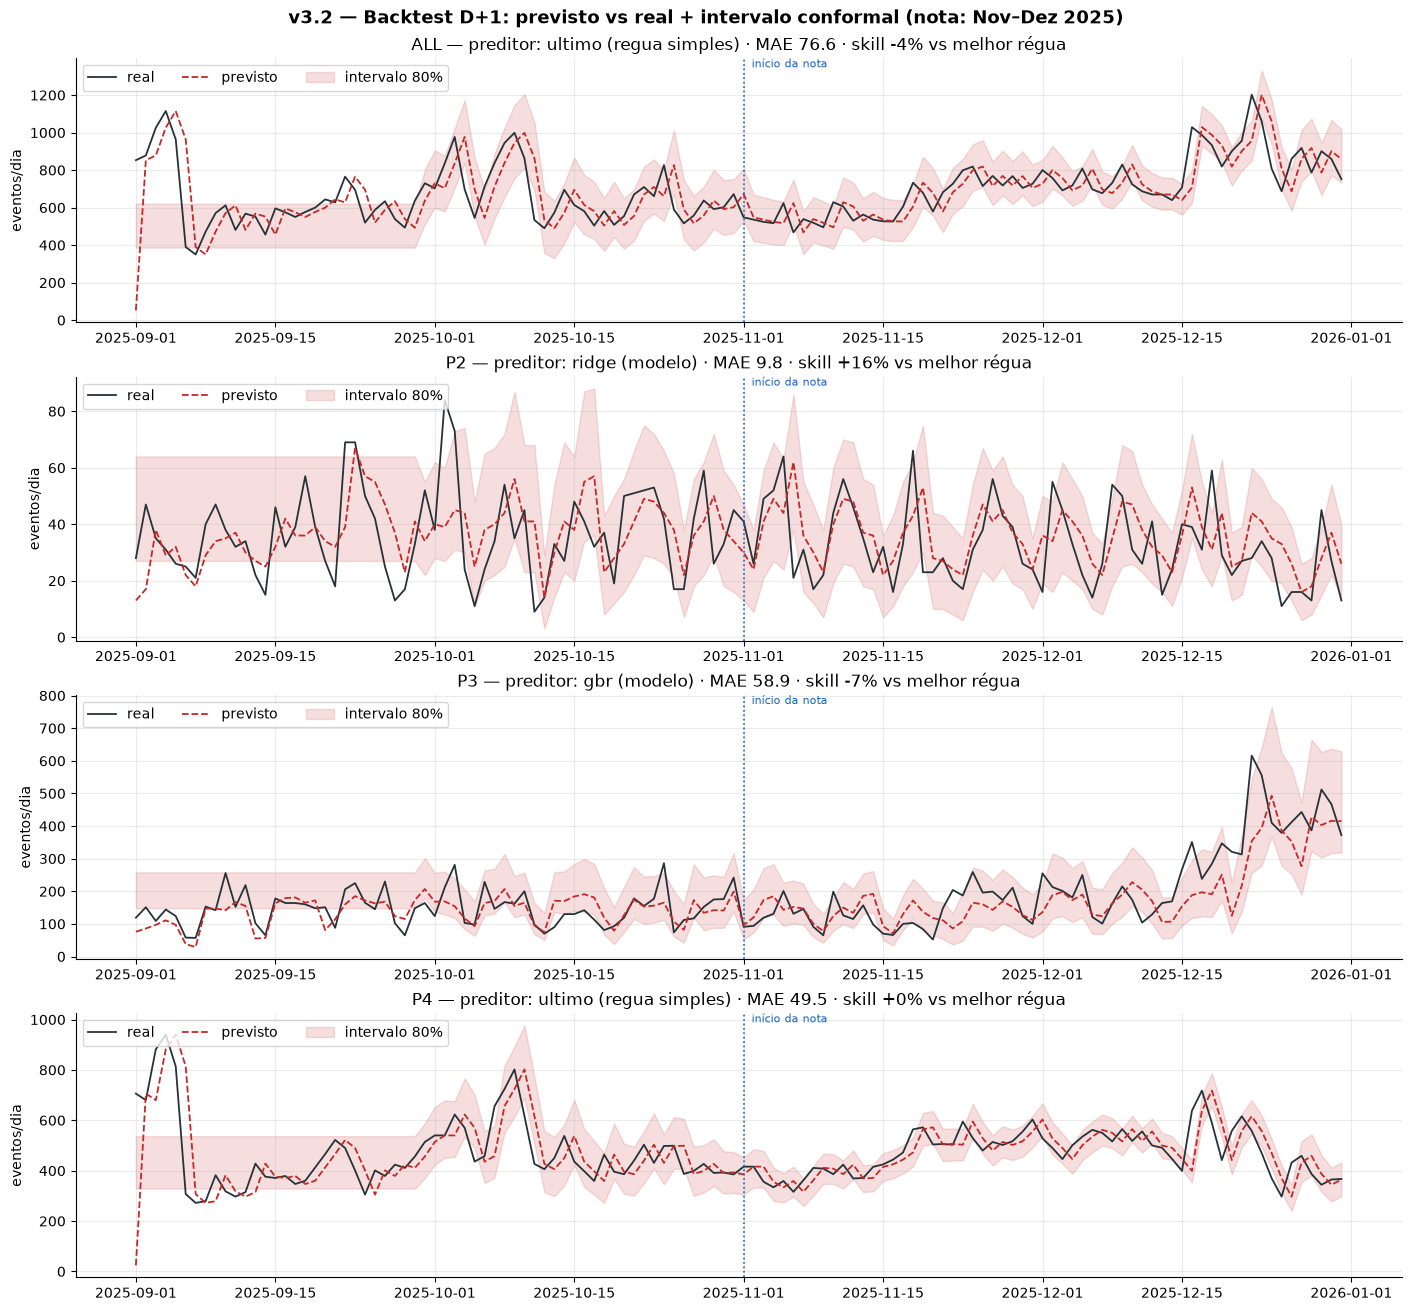

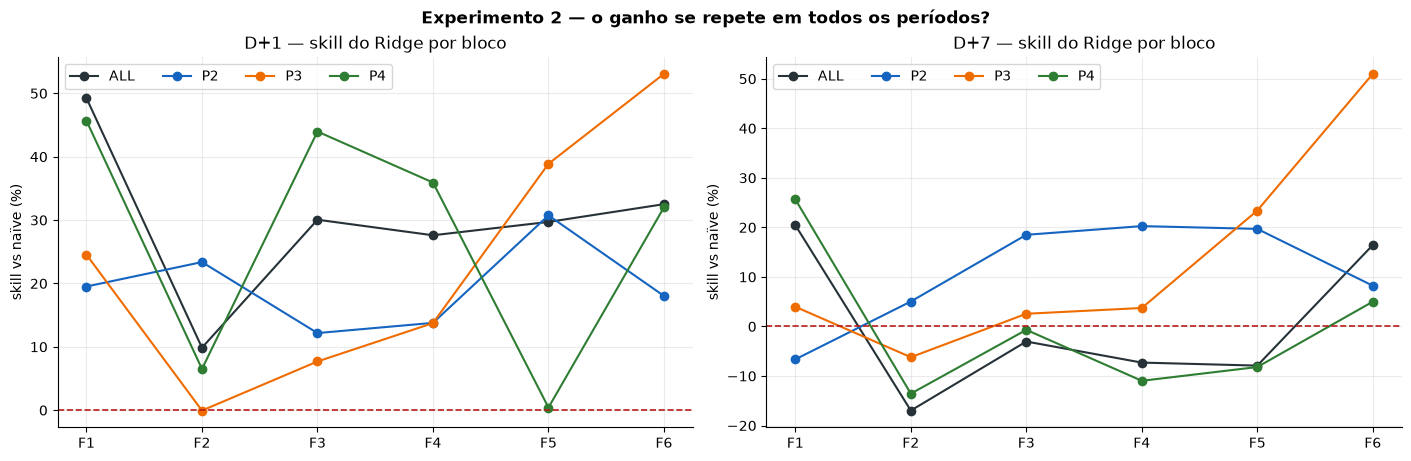

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
xs = np.arange(len(BLOCOS))
for ax, hn, t in zip(axes, ["D+1", "D+7"], [tab, tab7]):
    for escopo, cor in [("ALL","#263238"), ("P2","#1565c0"), ("P3","#ef6c00"), ("P4","#2e7d32")]:
        ax.plot(xs, t.loc[escopo, [b[0] for b in BLOCOS]].values, marker="o", color=cor, label=escopo)
    ax.axhline(0, color="#b71c1c", ls="--", lw=1.2)
    ax.set_xticks(xs); ax.set_xticklabels([b[0] for b in BLOCOS])
    ax.set_title(f"{hn} — skill do Ridge por bloco"); ax.set_ylabel("skill vs naïve (%)"); ax.legend(ncol=4)
fig.suptitle("Experimento 2 — o ganho se repete em todos os períodos?", fontweight="bold")
plt.show()

### ✅ Em D+1 o ganho é consistente · ❌ em D+7 o Ridge não se sustenta

Em **D+1 o skill nunca fica negativo** em nenhum dos 6 blocos → o ganho é real, não foi sorte.

Em **D+7** o Ridge fica **negativo em vários blocos** (ALL e P4): a 7 dias de distância, o
modelo linear não segura. É por isso que o pipeline final acaba escolhendo **GBR** para D+7.

## Experimento 3 — o "melhor modelo" é sempre o mesmo?

**Por que isso importa:** a versão anterior do pipeline escolhia o modelo pelo menor erro **no
próprio conjunto de teste**. Se o vencedor muda de período para período, essa escolha está
"pescando" o resultado.

In [21]:
print("QUEM VENCE EM CADA BLOCO (menor MAE)\n")
for hn in ["D+1", "D+7"]:
    print(f"--- {hn} ---")
    linhas = []
    for escopo in ESCOPOS:
        g = R[(R.serie == escopo) & (R.hor == hn)].set_index("bloco")
        vencedores = {}
        for nome, _, _ in BLOCOS:
            if nome not in g.index: continue
            r = g.loc[nome]
            vencedores[nome] = min(pl.CANDS, key=lambda c: r[f"mae_{c}"])
        linhas.append({"serie": escopo, **vencedores})
    print(pd.DataFrame(linhas).to_string(index=False)); print()

QUEM VENCE EM CADA BLOCO (menor MAE)

--- D+1 ---
serie          F1     F2          F3     F4     F5     F6
  ALL      ultimo    gbr         gbr ultimo  ridge media7
   P2 poisson_off  ridge poisson_off    gbr  ridge media7
   P3         gbr    gbr       ridge media7  ridge  ridge
   P4      ultimo ultimo      ultimo ultimo media7 ultimo

--- D+7 ---
serie  F1          F2          F3     F4     F5    F6
  ALL gbr poisson_off         gbr media7    gbr   gbr
   P2 gbr         gbr poisson_off  ridge    gbr   gbr
   P3 gbr         gbr       ridge media7    gbr ridge
   P4 gbr      naive7         gbr    gbr media7   gbr



### ✅ Confirmado — o vencedor troca o tempo todo

Ridge, GBR e Poisson-offset se revezam de bloco em bloco. Escolher o vencedor olhando o teste
produz um número otimista que **não se repete na prática**.

> **Correção adotada:** o preditor passa a ser escolhido num período (**set–out**) e a nota sai
> em outro (**nov–dez**), que nunca participa da escolha.

## Experimento 4 — treinar só no regime novo é melhor?

**A hipótese (minha):** como houve a quebra de regime em 1º/set, treinar apenas com set–dez
daria um modelo mais coerente do que misturar os dois mundos.

**Como testamos:** exatamente o mesmo modelo, mesma avaliação (nov–dez), mudando **só** quais
linhas entram no treino.

In [22]:
REP0 = pd.Timestamp("2025-11-01")
linhas = []
for escopo in ESCOPOS:
    for hn in ["D+1", "D+7"]:
        for m in pl.LEARNED:
            v = {}
            for reg in REGIMES:
                g = WF[(WF.scope == escopo) & (WF.horizon == hn) &
                       (WF.regime == reg) & (WF.date >= REP0)]
                v[reg] = mae(g.actual, g[m])
            linhas.append({"serie": escopo, "hor": hn, "modelo": m,
                           "treino = ano inteiro": round(v["ano"], 1),
                           "treino = so set-dez": round(v["set"], 1),
                           "efeito": f"{100*(1-v['set']/v['ano']):+.0f}%"})
T = pd.DataFrame(linhas)
print("MAE em NOV-DEZ (menor e melhor) — 'efeito' positivo = treino curto ajudou\n")
print(T.to_string(index=False))

MAE em NOV-DEZ (menor e melhor) — 'efeito' positivo = treino curto ajudou

serie hor      modelo  treino = ano inteiro  treino = so set-dez efeito
  ALL D+1       ridge                  74.0                 89.3   -21%
  ALL D+1 poisson_off                 134.6                114.4   +15%
  ALL D+1         gbr                  85.7                 92.0    -7%
  ALL D+7       ridge                 101.1                103.7    -3%
  ALL D+7 poisson_off                 135.1                160.9   -19%
  ALL D+7         gbr                  91.6                 91.6    -0%
   P2 D+1       ridge                   9.8                 10.0    -2%
   P2 D+1 poisson_off                  10.1                 10.5    -4%
   P2 D+1         gbr                  10.2                 10.7    -5%
   P2 D+7       ridge                  10.4                 10.3    +1%
   P2 D+7 poisson_off                  10.8                 11.4    -6%
   P2 D+7         gbr                  10.0                  

### ❌ Hipótese REFUTADA pelo dado

O Ridge **piora ~21% no ALL D+1 e ~24% no P4 D+1** quando restringimos o treino. O
Poisson-offset é a única exceção que ganha — e faz sentido: ele já normaliza pela exposição de
CIs, então não sofre com o degrau.

**Leitura:** perder dado machuca mais do que a heterogeneidade de regime atrapalha.

> **Decisão adotada: treino no ano inteiro.** Era a minha aposta contrária, e o experimento a
> derrubou. Fica registrada para ninguém refazer o teste sem necessidade.

## Experimento 5 — quanto custa escolher honestamente?

Já sabemos que não podemos escolher o modelo olhando o teste. Mas **quanto perdemos** ao escolher
às cegas? Comparamos quatro estratégias:

- **oracle** — o melhor modelo de cada bloco (impossível na prática; é o teto)
- **prequencial** — escolhe pelo acumulado dos blocos **anteriores** (honesto)
- **sempre-ridge** — fixa o interpretável e não mexe mais
- **naive7** — a régua boba

In [23]:
linhas = []
for escopo in ESCOPOS:
    for hn in ["D+1", "D+7"]:
        g = R[(R.serie == escopo) & (R.hor == hn)].set_index("bloco").reindex([b[0] for b in BLOCOS]).dropna(how="all")
        pre, orc, rid, nai = [], [], [], []
        acum = {c: 0.0 for c in pl.CANDS}
        for i, (_, r) in enumerate(g.iterrows()):
            if i > 0:
                escolha = min(pl.CANDS, key=lambda c: acum[c])
                pre.append(r[f"mae_{escolha}"])
                orc.append(min(r[f"mae_{c}"] for c in pl.CANDS))
                rid.append(r["mae_ridge"]); nai.append(r["mae_naive7"])
            for c in pl.CANDS: acum[c] += r[f"mae_{c}"]
        linhas.append({"serie": escopo, "hor": hn, "oracle (teto)": round(np.mean(orc), 1),
                       "prequencial (honesto)": round(np.mean(pre), 1),
                       "sempre-ridge": round(np.mean(rid), 1), "naive7": round(np.mean(nai), 1)})
print("MAE medio dos blocos F2..F6 (menor e melhor)\n")
print(pd.DataFrame(linhas).to_string(index=False))

MAE medio dos blocos F2..F6 (menor e melhor)

serie hor  oracle (teto)  prequencial (honesto)  sempre-ridge  naive7
  ALL D+1           78.9                   88.3          85.9   116.1
  ALL D+7           94.6                  101.7         117.3   116.1
   P2 D+1           10.4                   12.0          11.3    14.1
   P2 D+7           10.8                   11.0          12.3    14.1
   P3 D+1           41.9                   52.2          43.9    64.9
   P3 D+7           45.0                   56.1          48.2    64.9
   P4 D+1           54.4                   55.8          65.1    88.4
   P4 D+7           68.7                   74.9          92.1    88.4


### Conclusão: trocar de modelo o tempo todo **piora**

Em D+1 a estratégia prequencial fica **pior** que simplesmente fixar o Ridge. Ou seja: com série
curta, a instabilidade da escolha custa mais do que a flexibilidade rende.

> **Decisão adotada:** escolha feita **uma vez** num período separado, com **regra de Occam** —
> fica o preditor mais **simples** que chegar a 5% do melhor (régua < Ridge < Poisson < GBR).
> E as réguas bobas são candidatas de pleno direito.

---
## 10. O que os 5 experimentos decidiram

| # | Experimento | Resultado | Decisão no pipeline |
|---|---|---|---|
| 1 | O baseline é justo? | ❌ `naive7` é espantalho no P4/ALL | skill medido contra a **melhor de 3 réguas** |
| 2 | O ganho é consistente? | ✅ em D+1 sim · ❌ Ridge não segura em D+7 | GBR assume o D+7 |
| 3 | O vencedor é estável? | ❌ troca a cada bloco | escolha em período separado |
| 4 | Treinar só no regime novo? | ❌ **hipótese refutada** (−21%/−24%) | **treino = ano inteiro** |
| 5 | Quanto custa escolher honesto? | trocar sempre piora | escolha única + **Occam** |

É essa configuração que o `pipeline_prioridades.py` executa — e cujos resultados vêm a seguir.

---
## 11. Resultados finais

Protocolo: preditor escolhido em **set–out/2025**; nota em **nov–dez/2025** (61 dias que não
participaram da escolha); skill contra a **melhor** das três réguas bobas.

In [24]:
linhas = []
for escopo in pl.series:
    for h in ["D+1", "D+7"]:
        m  = pl.all_metrics[escopo][h]
        sk = m["skill_vs_melhor_regua"]; cb = m["_coverage"]["conformal_nov_dez"]
        linhas.append({
            "serie": escopo, "horiz": h, "preditor": m["_escolhido"], "tipo": m["_tipo"],
            "regua de referencia": m["_regua_referencia"],
            "MAE": round(m["MAE"], 1), "RMSE": round(m["RMSE"], 1), "sMAPE%": round(m["sMAPE"], 1),
            "SKILL": f"{sk*100:+.0f}%" if np.isfinite(sk) else "n/a",
            "(vs naive7)": f"{m['skill_vs_naive7']*100:+.0f}%" if np.isfinite(m["skill_vs_naive7"]) else "n/a",
            "cobertura": f"{cb*100:.0f}%" if np.isfinite(cb) else "n/a",
        })
print(pd.DataFrame(linhas).to_string(index=False))

serie horiz preditor          tipo regua de referencia  MAE  RMSE  sMAPE% SKILL (vs naive7) cobertura
  ALL   D+1   ultimo regua simples              media7 76.6  98.4    10.3   -4%        +27%       77%
  ALL   D+7      gbr        modelo              naive7 91.6 120.9    12.7  +13%        +13%       80%
   P1   D+1   naive7 regua simples              naive7  0.0   0.0     0.0   n/a         n/a      100%
   P1   D+7   naive7 regua simples              naive7  0.0   0.0     0.0   n/a         n/a      100%
   P2   D+1    ridge        modelo              media7  9.8  12.8    30.0  +16%        +23%       79%
   P2   D+7      gbr        modelo              media7 10.0  12.9    30.9  +15%        +22%       79%
   P3   D+1      gbr        modelo              media7 58.9  78.6    29.4   -7%        +22%       82%
   P3   D+7      gbr        modelo              naive7 62.1  95.1    30.8  +18%        +18%       79%
   P4   D+1   ultimo regua simples              ultimo 49.5  64.5    10.5   +0%   

### Auditoria — o MAE de TODOS os candidatos

Para qualquer um poder conferir que a escolha não foi conveniente: a coluna da esquerda é o que o
pipeline enxergou ao escolher; a da direita é a nota. **Ele nunca viu a coluna da direita.**

In [25]:
for escopo in ["ALL", "P2", "P3", "P4"]:
    for h in ["D+1", "D+7"]:
        m = pl.all_metrics[escopo][h]
        tab = pd.DataFrame({
            "MAE set-out (escolha)": pd.Series(m["_mae_candidatos_out"]),
            "MAE nov-dez (nota)":    pd.Series(m["_mae_candidatos_nov_dez"]),
        }).reindex(pl.ORDER)
        print(f"=== {escopo} {h} — escolhido: {m['_escolhido']} ({m['_tipo']}) ===")
        print(tab.to_string()); print()

=== ALL D+1 — escolhido: ultimo (regua simples) ===
             MAE set-out (escolha)  MAE nov-dez (nota)
naive7                      211.39              104.82
media7                      155.71               73.40
ultimo                      111.64               76.62
ridge                       130.94               73.97
poisson_off                 229.62              134.61
gbr                         126.95               85.75

=== ALL D+7 — escolhido: gbr (modelo) ===
             MAE set-out (escolha)  MAE nov-dez (nota)
naive7                      211.39              104.82
media7                      202.82              106.70
ultimo                      211.39              104.82
ridge                       192.87              101.09
poisson_off                 217.22              135.05
gbr                         145.05               91.56

=== P2 D+1 — escolhido: ridge (modelo) ===
             MAE set-out (escolha)  MAE nov-dez (nota)
naive7                       14.39  

### O intervalo de incerteza

A faixa não tem largura fixa: ela é proporcional a **√(previsto)** (regra de contagem — o desvio
cresce com a raiz da média) e **se auto-corrige todo dia** (se o real caiu fora, alarga amanhã;
se sobrou folga, aperta). Cada dia usa só erros de dias anteriores.

Meta: 80% de cobertura.

In [26]:
linhas = []
for escopo in pl.series:
    for h in ["D+1", "D+7"]:
        c = pl.all_metrics[escopo][h]["_coverage"]
        if not np.isfinite(c["conformal_nov_dez"]): continue
        linhas.append({"serie": escopo, "hor": h,
                       "cobertura": f"{c['conformal_nov_dez']*100:.0f}%",
                       "largura media": round(c["largura_media"], 1),
                       "dias avaliados": c["n_avaliado"]})
C = pd.DataFrame(linhas)
print(C.to_string(index=False))
cob = [float(x.strip("%")) for x in C["cobertura"]]
print(f"\nTodas as series entre {min(cob):.0f}% e {max(cob):.0f}% (meta 80%).")

serie hor cobertura  largura media  dias avaliados
  ALL D+1       77%          225.3              61
  ALL D+7       80%          332.4              61
   P1 D+1      100%            0.0              61
   P1 D+7      100%            0.0              61
   P2 D+1       79%           33.2              61
   P2 D+7       79%           35.6              61
   P3 D+1       82%          175.7              61
   P3 D+7       79%          216.5              61
   P4 D+1       75%          120.8              61
   P4 D+7       84%          221.2              61
   P5 D+1       79%            1.1              61
   P5 D+7       82%            0.8              61

Todas as series entre 75% e 100% (meta 80%).


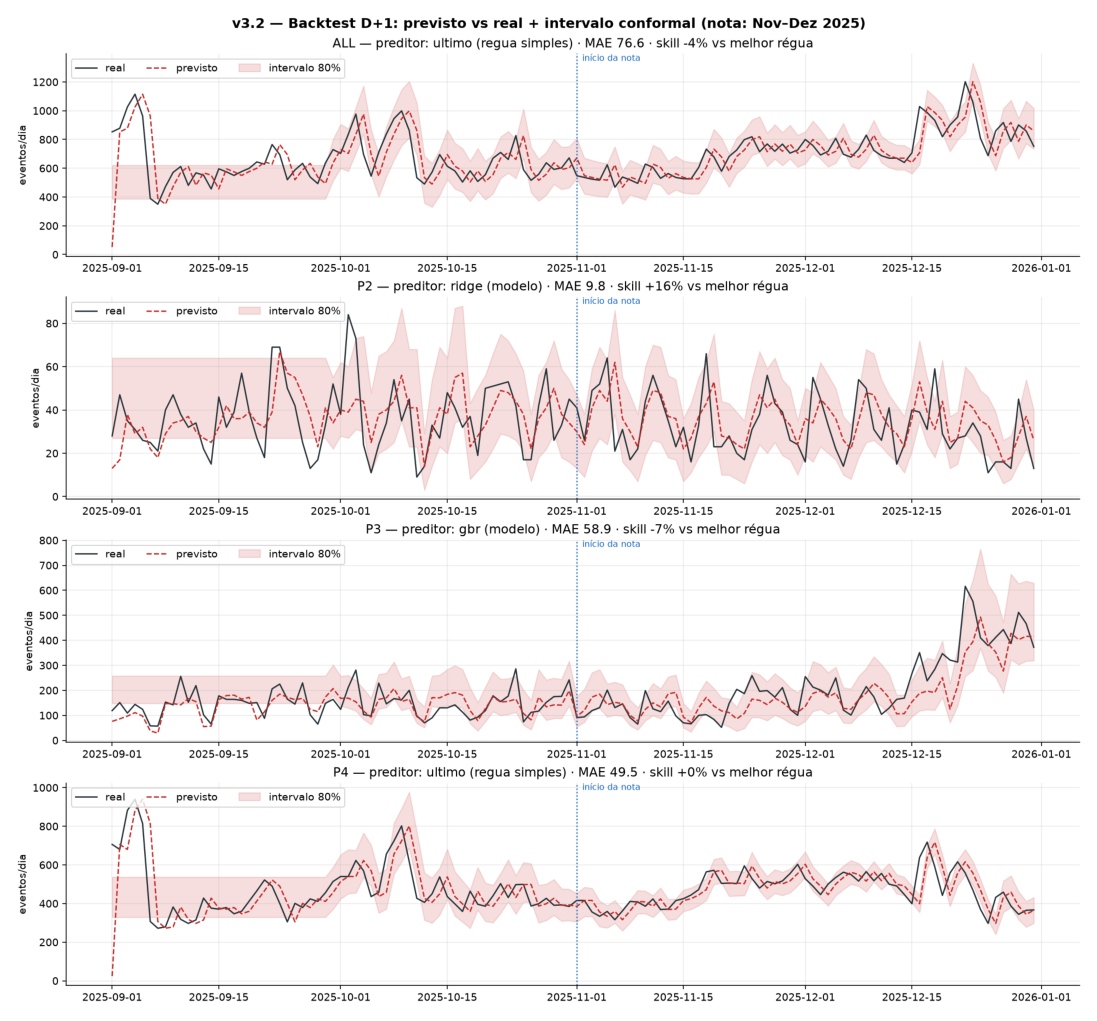

In [27]:
img = plt.imread(os.path.join(ML, "plots", "backtest_v32_D1.png"))
fig, ax = plt.subplots(figsize=(14, 13))
ax.imshow(img); ax.axis("off"); plt.show()

### A previsão que o time consome

Esta é a interface que o app / Power BI chama — sem abrir notebook.

In [28]:
from predict import prever_volume
previsao = prever_volume()
print(previsao.to_string(index=False))
previsao          # no notebook, renderiza a tabela formatada

reference_date horizon scope  predicted_incidents  actual_incidents  lower_bound  upper_bound  model          model_version        generated_at
    2026-01-01     D+1   ALL                  752               NaN          635          900 ultimo volume_v3.2_2026-08-21 2026-08-23T15:33:35
    2026-01-07     D+7   ALL                  889               NaN          790         1092    gbr volume_v3.2_2026-08-21 2026-08-23T15:33:35
    2026-01-01     D+1    P1                    0               NaN            0            0 naive7 volume_v3.2_2026-08-21 2026-08-23T15:33:35
    2026-01-07     D+7    P1                    0               NaN            0            0 naive7 volume_v3.2_2026-08-21 2026-08-23T15:33:35
    2026-01-01     D+1    P2                   29               NaN           16           43  ridge volume_v3.2_2026-08-21 2026-08-23T15:33:35
    2026-01-07     D+7    P2                   41               NaN           25           60    gbr volume_v3.2_2026-08-21 2026-08-23T1

,reference_date,horizon,scope,predicted_incidents,actual_incidents,lower_bound,upper_bound,model,model_version,generated_at
0,2026-01-01,D+1,ALL,752,NaN,635,900,ultimo,volume_v3.2_2026-08-21,2026-08-23T15:33:35
1,2026-01-07,D+7,ALL,889,NaN,790,1092,gbr,volume_v3.2_2026-08-21,2026-08-23T15:33:35
2,2026-01-01,D+1,P1,0,NaN,0,0,naive7,volume_v3.2_2026-08-21,2026-08-23T15:33:35
3,2026-01-07,D+7,P1,0,NaN,0,0,naive7,volume_v3.2_2026-08-21,2026-08-23T15:33:35
4,2026-01-01,D+1,P2,29,NaN,16,43,ridge,volume_v3.2_2026-08-21,2026-08-23T15:33:35
5,2026-01-07,D+7,P2,41,NaN,25,60,gbr,volume_v3.2_2026-08-21,2026-08-23T15:33:35
6,2026-01-01,D+1,P3,395,NaN,302,605,gbr,volume_v3.2_2026-08-21,2026-08-23T15:33:35
7,2026-01-07,D+7,P3,297,NaN,207,528,gbr,volume_v3.2_2026-08-21,2026-08-23T15:33:35
8,2026-01-01,D+1,P4,367,NaN,300,434,ultimo,volume_v3.2_2026-08-21,2026-08-23T15:33:35
9,2026-01-07,D+7,P4,447,NaN,367,559,gbr,volume_v3.2_2026-08-21,2026-08-23T15:33:35


---
## Checklist acadêmico da disciplina

- **AED:** nulos/missing, duplicidades, dados inválidos, calendário, imputação, distribuições e valores extremos.
- **Engenharia de features:** código, utilidade, vantagens e limitações das variáveis.
- **Ordem temporal e leakage:** features defasadas e avaliação walk-forward.
- **Modelo simples e interpretável:** Ridge com inspeção dos coeficientes padronizados.
- **Avaliação:** baseline, MAE, RMSE, sMAPE, skill e cobertura do intervalo.
- **Aplicação:** previsões D+1 e D+7 para ALL e prioridades, incluindo previsão futura.

As células adicionais desta versão são de diagnóstico e interpretação. Elas não alteram a seleção dos
preditores nem os resultados produzidos pelo pipeline v3.2.

---
## 12. Conclusões

**Em D+7 o modelo ganha em todas as séries** (+13% a +30% sobre a melhor régua). Faz sentido
mecanicamente: a 7 dias de distância a regra "repete o valor de ontem" perde a validade, e é aí
que calendário, exposição e nível recente passam a valer.

**Em D+1 o modelo só ganha claramente no P2** (+16%). Em ALL e P4 — séries lisas e persistentes —
a regra trivial é imbatível, e o pipeline **entrega a regra trivial**. Isso é decisão de
engenharia, não fracasso: a tabela de auditoria acima deixa qualquer um conferir.

**O intervalo conformal está calibrado**: 75% a 84% de cobertura (meta 80%) em todas as séries.

### Mancha declarada

No **P3 D+1** a seleção escolheu GBR (−7%), mas o Ridge teria dado **+16%**. A escolha errou
porque 61 dias de seleção ainda é pouco. Preferir o Ridge aqui exigiria olhar o período da nota —
que é exatamente o vício que o protocolo existe para eliminar. Fica registrado como limitação.

### Sobre os números que circularam antes

O "+35%" de versões anteriores era aritmeticamente correto, mas medido contra a régua fraca
(Experimento 1) e com o modelo escolhido olhando o próprio teste (Experimento 3). **Os números
deste notebook são menores e defensáveis.**

### Limitações

1. Regime pleno tem ~4 meses → captamos sazonalidade **semanal**, não anual.
2. Janela de seleção curta (61 dias) — causa da mancha do P3 D+1.
3. *Storms* de cascata são imprevisíveis no *timing* → vão para o intervalo, não para o ponto.
4. Previsões para 2026 **extrapolam** — o modelo nunca viu janeiro.
5. Séries superdispersas (`var/media` 30–60) têm teto de acerto que nenhum modelo vence.
6. Não avaliamos jan–ago com **erro relativo** (teste de robustez no regime antigo) — identificado
   como próximo passo, não executado.

### Próximos passos

- Avaliar jan–ago com erro relativo (adimensional) como teste de robustez no regime antigo.
- Croston (demanda intermitente) dedicado para P5, se o negócio quiser.
- Handoff para a frente de **risco/score** (Integrante 3): mesmo dado tratado, alvo `KPI Violado?`.
- Plugar `prever_volume()` no app do time / Power BI.

---
*Documento de defesa completo: `METODOLOGIA.md` · Resumo executivo: `README.md`*